# Final Experiments Clean Notebook

**Project:** Token-Efficient Multimodal Reasoning via Scene-to-Structured-Text (SST) Compression

This notebook is a cleaned record of the current successful project pipeline. It keeps the final reproducible stages and removes earlier toy/debug cells.

Core outputs produced or verified here:

- `real_gqa_200_publish_methods_detailed.csv`
- `final_200_sample_report_table.csv`
- `final_200_sample_mcnemar_vs_full_sst.csv`
- `llava_200_results_detailed.csv`
- `llava_200_evaluated.csv`
- `llava_200_summary.csv`
- `final_sst_vs_llava_comparison.csv`
- `final_error_analysis_*.csv`

Important framing: the SST branch uses **oracle GQA scene graphs**. It is not yet a fully automatic raw-image-to-SST pipeline.


In [1]:
# Cell 1: Setup paths and imports
# Purpose: Defines project folders and final result file paths.

from pathlib import Path
import os
import json
import pandas as pd
import numpy as np

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
IMAGE_DIR = DATA_DIR / "gqa_images_subset_200"
RESULTS_DIR = PROJECT_ROOT / "outputs" / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BALANCED_200_PATH = PROCESSED_DIR / "real_gqa_sst_200_balanced.json"
SST_DETAILED_PATH = RESULTS_DIR / "real_gqa_200_publish_methods_detailed.csv"
SST_REPORT_PATH = RESULTS_DIR / "final_200_sample_report_table.csv"
MCNEMAR_PATH = RESULTS_DIR / "final_200_sample_mcnemar_vs_full_sst.csv"
LLAVA_DETAILED_PATH = RESULTS_DIR / "llava_200_results_detailed.csv"
LLAVA_EVALUATED_PATH = RESULTS_DIR / "llava_200_evaluated.csv"
LLAVA_SUMMARY_PATH = RESULTS_DIR / "llava_200_summary.csv"

print("Project root:", PROJECT_ROOT.resolve())
print("Results dir:", RESULTS_DIR.resolve())


Project root: /Users/alisha/Documents/CSE427_SST_Project
Results dir: /Users/alisha/Documents/CSE427_SST_Project/outputs/results


In [2]:
# Cell 2: Verify final files
# Purpose: Checks whether required datasets/results exist before downstream analysis.

expected_files = {
    "Balanced 200 dataset": BALANCED_200_PATH,
    "SST detailed results": SST_DETAILED_PATH,
    "SST final report table": SST_REPORT_PATH,
    "SST McNemar table": MCNEMAR_PATH,
    "LLaVA detailed results": LLAVA_DETAILED_PATH,
    "LLaVA evaluated results": LLAVA_EVALUATED_PATH,
    "LLaVA summary": LLAVA_SUMMARY_PATH,
}

file_rows = []
for label, path in expected_files.items():
    file_rows.append({
        "file": label,
        "path": str(path),
        "exists": path.exists(),
        "size_mb": round(path.stat().st_size / (1024 * 1024), 3) if path.exists() else None,
    })

file_check_df = pd.DataFrame(file_rows)
display(file_check_df)

missing = file_check_df.loc[~file_check_df["exists"], "file"].tolist()
if missing:
    print("Missing files:", missing)
else:
    print("All expected final files are present.")

if BALANCED_200_PATH.exists():
    with open(BALANCED_200_PATH, "r") as f:
        balanced_samples = json.load(f)
    print("Balanced samples:", len(balanced_samples))


,file,path,exists,size_mb
0,Balanced 200 dataset,../data/processed/real_gqa_sst_200_balanced.json,True,0.588
1,SST detailed results,../outputs/results/real_gqa_200_publish_method...,True,2.888
2,SST final report table,../outputs/results/final_200_sample_report_tab...,True,0.001
3,SST McNemar table,../outputs/results/final_200_sample_mcnemar_vs...,True,0.001
4,LLaVA detailed results,../outputs/results/llava_200_results_detailed.csv,True,0.016
5,LLaVA evaluated results,../outputs/results/llava_200_evaluated.csv,True,0.020
6,LLaVA summary,../outputs/results/llava_200_summary.csv,True,0.000


All expected final files are present.
Balanced samples: 200


In [3]:
# Cell 3: Load final SST results
# Purpose: Displays final SST method table and paired statistical comparison.

sst_report_df = pd.read_csv(SST_REPORT_PATH)
mcnemar_df = pd.read_csv(MCNEMAR_PATH)

print("Final 200-sample SST report table:")
display(sst_report_df)

print("\nMcNemar-style paired comparison vs Full SST:")
display(mcnemar_df)


Final 200-sample SST report table:


,Method,Exact Accuracy,Lenient Accuracy,Avg Tokens,Median Tokens,Token Reduction vs Full SST (%),Accuracy Drop vs Full SST (points),Avg Latency (ms),N
0,Full SST,0.545,0.585,441.44,406.5,0.00,0.0,6624.88,200
1,Caption-Style SST,0.530,0.585,443.96,405.5,-0.57,1.5,6770.17,200
2,Keyword-Aware SST,0.500,0.570,215.53,203.0,51.18,4.5,2118.99,200
3,Compact Keyword-Aware SST,0.410,0.520,175.10,162.5,60.33,13.5,3474.82,200
4,No-Relations SST,0.430,0.430,153.79,153.0,65.16,11.5,2592.45,200
5,No-Attributes SST,0.400,0.430,403.84,373.5,8.52,14.5,5877.05,200
6,Objects-Only SST,0.225,0.240,106.24,106.0,75.93,32.0,2887.83,200



McNemar-style paired comparison vs Full SST:


,method,pipeline,full_sst_accuracy,method_accuracy,accuracy_difference_method_minus_full,both_correct,both_wrong,method_correct_full_wrong,full_correct_method_wrong,discordant_pairs,mcnemar_exact_p,significant_at_0.05,interpretation
0,Keyword-Aware SST,keyword_filtered_sst_mistral,0.545,0.500,-0.045,94,85,6,15,21,0.078354,False,not significantly different from Full SST
1,Compact Keyword-Aware SST,compact_keyword_sst_mistral,0.545,0.410,-0.135,75,84,7,34,41,0.000025,True,significantly different from Full SST
2,Objects-Only SST,objects_only_sst_mistral,0.545,0.225,-0.320,38,84,7,71,78,0.000000,True,significantly different from Full SST
3,No-Relations SST,no_relations_sst_mistral,0.545,0.430,-0.115,70,75,16,39,55,0.002667,True,significantly different from Full SST
4,No-Attributes SST,no_attributes_sst_mistral,0.545,0.400,-0.145,73,84,7,36,43,0.000009,True,significantly different from Full SST
5,Caption-Style SST,caption_style_sst_mistral,0.545,0.530,-0.015,102,87,4,7,11,0.548828,False,not significantly different from Full SST


In [4]:
# Cell 4: Download/verify 200-image subset
# Purpose: Downloads only the unique images needed for the 200-sample LLaVA baseline. Safe to rerun; existing files are skipped.

# Stage 1: Download only the 200 images needed for the balanced GQA subset

from pathlib import Path
import json, time, requests
from tqdm.auto import tqdm

# ---------- Locate project/data paths ----------
candidate_jsons = [
    Path("../data/processed/real_gqa_sst_200_balanced.json"),
    Path("data/processed/real_gqa_sst_200_balanced.json"),
    Path("../outputs/data/real_gqa_sst_200_balanced.json"),
    Path("outputs/data/real_gqa_sst_200_balanced.json"),
]

dataset_path = next((p for p in candidate_jsons if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError(
        "Could not find real_gqa_sst_200_balanced.json. "
        "Check where you saved it and update candidate_jsons."
    )

print("Found dataset:", dataset_path.resolve())

# Put images in the matching project data folder
if str(dataset_path).startswith("../"):
    image_dir = Path("../data/gqa_images_subset_200")
else:
    image_dir = Path("data/gqa_images_subset_200")

image_dir.mkdir(parents=True, exist_ok=True)
print("Saving images to:", image_dir.resolve())

# ---------- Load 200 balanced SST examples ----------
with open(dataset_path, "r") as f:
    samples = json.load(f)

print("Number of samples:", len(samples))

# Robust image id extraction
def get_image_id(sample):
    for key in ["image_id", "imageId", "imageID", "img_id"]:
        if key in sample:
            return str(sample[key])
    raise KeyError(f"No image id key found in sample keys: {list(sample.keys())}")

image_ids = sorted(set(get_image_id(s) for s in samples))
print("Unique image IDs:", len(image_ids))

# ---------- Download images ----------
base_urls = [
    "https://cs.stanford.edu/people/rak248/VG_100K/{image_id}.jpg",
    "https://cs.stanford.edu/people/rak248/VG_100K_2/{image_id}.jpg",
]

downloaded = []
already_exists = []
missing = []

session = requests.Session()
headers = {
    "User-Agent": "Mozilla/5.0"
}

for image_id in tqdm(image_ids, desc="Downloading GQA/VG images"):
    out_path = image_dir / f"{image_id}.jpg"

    if out_path.exists() and out_path.stat().st_size > 0:
        already_exists.append(image_id)
        continue

    success = False

    for url_template in base_urls:
        url = url_template.format(image_id=image_id)

        try:
            r = session.get(url, headers=headers, timeout=20)

            if r.status_code == 200 and len(r.content) > 1000:
                with open(out_path, "wb") as f:
                    f.write(r.content)

                downloaded.append(image_id)
                success = True
                break

        except requests.RequestException:
            pass

        time.sleep(0.05)

    if not success:
        missing.append(image_id)

# ---------- Save download report ----------
report = {
    "dataset_path": str(dataset_path),
    "image_dir": str(image_dir),
    "num_samples": len(samples),
    "num_unique_image_ids": len(image_ids),
    "downloaded_now": len(downloaded),
    "already_existed": len(already_exists),
    "available_total": len(downloaded) + len(already_exists),
    "missing": len(missing),
    "missing_image_ids": missing,
}

report_path = image_dir / "download_report.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("\nDownload summary")
print("----------------")
print("Downloaded now:", len(downloaded))
print("Already existed:", len(already_exists))
print("Available total:", len(downloaded) + len(already_exists), "/", len(image_ids))
print("Missing:", len(missing))
print("Report saved to:", report_path.resolve())

if missing:
    print("\nFirst missing IDs:", missing[:10])
else:
    print("\nAll required images are available.")

Found dataset: /Users/alisha/Documents/CSE427_SST_Project/data/processed/real_gqa_sst_200_balanced.json
Saving images to: /Users/alisha/Documents/CSE427_SST_Project/data/gqa_images_subset_200
Number of samples: 200
Unique image IDs: 198



Download summary
----------------
Downloaded now: 0
Already existed: 198
Available total: 198 / 198
Missing: 0
Report saved to: /Users/alisha/Documents/CSE427_SST_Project/data/gqa_images_subset_200/download_report.json

All required images are available.


In [5]:
# Cell 5: Run 5-sample LLaVA smoke test
# Purpose: Verifies that local Ollama LLaVA can answer image-question inputs and saves smoke-test CSV.

# Stage 2: LLaVA smoke test on 5 GQA images
# Saves to ../outputs/results/llava_5_sample_smoke_test.csv

import os
import json
import base64
import requests
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/processed/real_gqa_sst_200_balanced.json")
IMAGE_DIR = Path("../data/gqa_images_subset_200")
RESULTS_DIR = Path("../outputs/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_PATH, "r") as f:
    samples = json.load(f)

samples_5 = samples[:5]

def encode_image_base64(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def query_llava(image_path, question):
    image_b64 = encode_image_base64(image_path)

    prompt = f"""
Answer the question based only on the image.
Be concise. Answer with a short phrase or single word.

Question: {question}
Answer:
""".strip()

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "llava",
            "prompt": prompt,
            "images": [image_b64],
            "stream": False
        },
        timeout=180
    )

    response.raise_for_status()
    result = response.json()
    return result.get("response", "").strip()

rows = []

for i, sample in enumerate(samples_5, start=1):
    image_id = str(sample.get("image_id") or sample.get("imageId"))
    question = sample["question"]
    ground_truth = sample["answer"]
    image_path = IMAGE_DIR / f"{image_id}.jpg"

    print(f"Running LLaVA smoke sample {i}/5 | image_id={image_id}")

    if not image_path.exists():
        prediction = "IMAGE_NOT_FOUND"
    else:
        try:
            prediction = query_llava(image_path, question)
        except Exception as e:
            prediction = f"ERROR: {repr(e)}"

    rows.append({
        "sample_index": i,
        "image_id": image_id,
        "question": question,
        "ground_truth": ground_truth,
        "prediction": prediction,
        "image_path": str(image_path)
    })

llava_smoke_df = pd.DataFrame(rows)

smoke_path = RESULTS_DIR / "llava_5_sample_smoke_test.csv"
llava_smoke_df.to_csv(smoke_path, index=False)

print("\nSaved smoke-test results to:")
print(smoke_path.resolve())

display(llava_smoke_df)

Running LLaVA smoke sample 1/5 | image_id=2409655
Running LLaVA smoke sample 2/5 | image_id=2352072
Running LLaVA smoke sample 3/5 | image_id=2388049
Running LLaVA smoke sample 4/5 | image_id=2392384
Running LLaVA smoke sample 5/5 | image_id=2352021

Saved smoke-test results to:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/llava_5_sample_smoke_test.csv


,sample_index,image_id,question,ground_truth,prediction,image_path
0,1,2409655,On which side of the picture is the chimney?,right,Right,../data/gqa_images_subset_200/2409655.jpg
1,2,2352072,"What material do you think is the boot, rubber...",rubber,Rubber,../data/gqa_images_subset_200/2352072.jpg
2,3,2388049,Is the camera in the bottom part or in the top...,top,Bottom,../data/gqa_images_subset_200/2388049.jpg
3,4,2392384,Is that bus teal and long?,yes,Yes,../data/gqa_images_subset_200/2392384.jpg
4,5,2352021,On which side of the image is the toilet paper?,right,Left,../data/gqa_images_subset_200/2352021.jpg


In [6]:
# Cell 6: Run or resume full 200-sample LLaVA baseline
# Optional/expensive: run only if you need to regenerate this output.
# Purpose: Runs direct Image + Question → LLaVA. Uses sample_index so duplicate images with different questions are handled correctly.

# Stage 3B: Correct/complete full 200-sample LLaVA evaluation
# Uses sample index, not image_id, because multiple GQA questions can share the same image.

import time
import json
import base64
import requests
import pandas as pd
from pathlib import Path

# ---------- Paths ----------
DATA_PATH = Path("../data/processed/real_gqa_sst_200_balanced.json")
IMAGE_DIR = Path("../data/gqa_images_subset_200")
RESULTS_DIR = Path("../outputs/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = RESULTS_DIR / "llava_200_results_detailed.csv"

# ---------- Load data ----------
with open(DATA_PATH, "r") as f:
    samples = json.load(f)

print("Expected number of question samples:", len(samples))

# ---------- Load existing results if present ----------
if OUTPUT_PATH.exists():
    existing_df = pd.read_csv(OUTPUT_PATH)

    # Ensure there is a sample_index column.
    # Older version used "index"; convert safely.
    if "sample_index" not in existing_df.columns:
        if "index" in existing_df.columns:
            existing_df["sample_index"] = existing_df["index"]
        else:
            raise ValueError("Existing results file has no sample_index or index column.")

    existing_df["sample_index"] = existing_df["sample_index"].astype(int)

    done_indices = set(existing_df["sample_index"].tolist())
    rows = existing_df.to_dict("records")

    print(f"Existing saved rows: {len(existing_df)}")
    print(f"Existing completed sample indices: {len(done_indices)}")
else:
    done_indices = set()
    rows = []
    print("No existing LLaVA detailed results found. Starting fresh.")

# ---------- Helpers ----------
def encode_image_base64(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def query_llava(image_path, question):
    image_b64 = encode_image_base64(image_path)

    prompt = f"""
Answer the question based only on the image.
Be concise. Answer with a short phrase or single word.

Question: {question}
Answer:
""".strip()

    start = time.time()

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "llava",
            "prompt": prompt,
            "images": [image_b64],
            "stream": False
        },
        timeout=180
    )

    response.raise_for_status()
    result = response.json()
    latency = time.time() - start

    return result.get("response", "").strip(), latency

# ---------- Complete missing samples ----------
for sample_index, sample in enumerate(samples):
    if sample_index in done_indices:
        continue

    image_id = str(sample.get("image_id") or sample.get("imageId"))
    question = sample["question"]
    ground_truth = sample["answer"]
    image_path = IMAGE_DIR / f"{image_id}.jpg"

    print(f"Running sample {sample_index + 1}/200 | image_id={image_id}")

    if not image_path.exists():
        prediction, latency = "IMAGE_NOT_FOUND", 0.0
    else:
        try:
            prediction, latency = query_llava(image_path, question)
        except Exception as e:
            prediction, latency = f"ERROR: {repr(e)}", 0.0

    rows.append({
        "sample_index": sample_index,
        "image_id": image_id,
        "question": question,
        "ground_truth": ground_truth,
        "prediction": prediction,
        "latency_sec": latency,
        "image_path": str(image_path)
    })

    done_indices.add(sample_index)

    # checkpoint every 10 completed rows
    if len(rows) % 10 == 0:
        temp_df = pd.DataFrame(rows)
        temp_df = temp_df.drop_duplicates(subset=["sample_index"], keep="last")
        temp_df = temp_df.sort_values("sample_index")
        temp_df.to_csv(OUTPUT_PATH, index=False)
        print(f"Checkpoint saved: {len(temp_df)} rows")

# ---------- Final clean save ----------
final_df = pd.DataFrame(rows)

# Keep one row per sample index, sorted
final_df = final_df.drop_duplicates(subset=["sample_index"], keep="last")
final_df = final_df.sort_values("sample_index")

final_df.to_csv(OUTPUT_PATH, index=False)

print("\nSaved corrected full LLaVA results to:")
print(OUTPUT_PATH.resolve())

print("\nFinal row count:", len(final_df))
print("Expected row count:", len(samples))
print("Missing sample indices:", sorted(set(range(len(samples))) - set(final_df["sample_index"].astype(int))))

print("\nError rows:")
error_mask = final_df["prediction"].astype(str).str.startswith("ERROR") | (final_df["prediction"].astype(str) == "IMAGE_NOT_FOUND")
print(error_mask.sum())

display(final_df.head())

Expected number of question samples: 200
Existing saved rows: 200
Existing completed sample indices: 200

Saved corrected full LLaVA results to:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/llava_200_results_detailed.csv

Final row count: 200
Expected row count: 200
Missing sample indices: []

Error rows:
0


,index,image_id,question,ground_truth,prediction,latency_sec,sample_index
0,0,2409655,On which side of the picture is the chimney?,right,Right,4.634887,0
1,1,2352072,"What material do you think is the boot, rubber...",rubber,Rubber,4.552055,1
2,2,2388049,Is the camera in the bottom part or in the top...,top,Bottom,4.459397,2
3,3,2392384,Is that bus teal and long?,yes,Yes,4.429357,3
4,4,2352021,On which side of the image is the toilet paper?,right,Left,4.398647,4


In [7]:
# Cell 7: Evaluate LLaVA baseline
# Purpose: Normalizes answers, computes exact/lenient accuracy and latency summary, and saves evaluated CSVs.

# Stage 4: Evaluate LLaVA 200-sample results
# Saves:
# - ../outputs/results/llava_200_evaluated.csv
# - ../outputs/results/llava_200_summary.csv

import re
import pandas as pd
import numpy as np
from pathlib import Path

RESULTS_DIR = Path("../outputs/results")
LLAVA_PATH = RESULTS_DIR / "llava_200_results_detailed.csv"

EVALUATED_PATH = RESULTS_DIR / "llava_200_evaluated.csv"
SUMMARY_PATH = RESULTS_DIR / "llava_200_summary.csv"

llava_df = pd.read_csv(LLAVA_PATH)

# ---------- Answer normalization ----------
NUMBER_WORDS = {
    "zero": "0",
    "one": "1",
    "two": "2",
    "three": "3",
    "four": "4",
    "five": "5",
    "six": "6",
    "seven": "7",
    "eight": "8",
    "nine": "9",
    "ten": "10",
}

ARTICLES = {"a", "an", "the"}

def normalize_answer(x):
    if pd.isna(x):
        return ""

    x = str(x).lower().strip()

    # remove common prefixes from model outputs
    prefixes = [
        "answer:",
        "the answer is",
        "it is",
        "it's",
        "i think it is",
        "i think",
    ]
    for p in prefixes:
        if x.startswith(p):
            x = x[len(p):].strip()

    # remove punctuation
    x = re.sub(r"[^a-z0-9\s]", " ", x)

    # normalize whitespace
    tokens = x.split()

    # remove articles
    tokens = [t for t in tokens if t not in ARTICLES]

    # map number words
    tokens = [NUMBER_WORDS.get(t, t) for t in tokens]

    return " ".join(tokens).strip()

def exact_match(pred, gt):
    return normalize_answer(pred) == normalize_answer(gt)

def lenient_match(pred, gt):
    pred_n = normalize_answer(pred)
    gt_n = normalize_answer(gt)

    if pred_n == gt_n:
        return True

    if pred_n == "" or gt_n == "":
        return False

    # For yes/no questions, avoid substring false positives
    if gt_n in {"yes", "no"}:
        return pred_n == gt_n

    pred_tokens = set(pred_n.split())
    gt_tokens = gt_n.split()

    # If ground truth is one token, allow it to appear as a standalone token
    if len(gt_tokens) == 1:
        return gt_tokens[0] in pred_tokens

    # For multi-token answers, allow phrase containment
    return gt_n in pred_n

# ---------- Evaluate ----------
llava_df["prediction_normalized"] = llava_df["prediction"].apply(normalize_answer)
llava_df["ground_truth_normalized"] = llava_df["ground_truth"].apply(normalize_answer)

llava_df["exact_correct"] = llava_df.apply(
    lambda r: exact_match(r["prediction"], r["ground_truth"]),
    axis=1
)

llava_df["lenient_correct"] = llava_df.apply(
    lambda r: lenient_match(r["prediction"], r["ground_truth"]),
    axis=1
)

# ---------- Summary ----------
summary = {
    "method": "LLaVA Image + Question",
    "n": len(llava_df),
    "exact_accuracy": llava_df["exact_correct"].mean(),
    "lenient_accuracy": llava_df["lenient_correct"].mean(),
    "num_exact_correct": int(llava_df["exact_correct"].sum()),
    "num_lenient_correct": int(llava_df["lenient_correct"].sum()),
    "avg_latency_sec": llava_df["latency_sec"].mean(),
    "median_latency_sec": llava_df["latency_sec"].median(),
    "min_latency_sec": llava_df["latency_sec"].min(),
    "max_latency_sec": llava_df["latency_sec"].max(),
}

summary_df = pd.DataFrame([summary])

# ---------- Save ----------
llava_df.to_csv(EVALUATED_PATH, index=False)
summary_df.to_csv(SUMMARY_PATH, index=False)

print("Saved evaluated LLaVA results to:")
print(EVALUATED_PATH.resolve())

print("\nSaved LLaVA summary to:")
print(SUMMARY_PATH.resolve())

print("\nLLaVA Summary")
print("-------------")
print(f"N: {summary['n']}")
print(f"Exact accuracy: {summary['exact_accuracy']:.3f} ({summary['exact_accuracy']*100:.1f}%)")
print(f"Lenient accuracy: {summary['lenient_accuracy']:.3f} ({summary['lenient_accuracy']*100:.1f}%)")
print(f"Avg latency: {summary['avg_latency_sec']:.2f} sec")
print(f"Median latency: {summary['median_latency_sec']:.2f} sec")

display(summary_df)
display(llava_df.head())

Saved evaluated LLaVA results to:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/llava_200_evaluated.csv

Saved LLaVA summary to:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/llava_200_summary.csv

LLaVA Summary
-------------
N: 200
Exact accuracy: 0.555 (55.5%)
Lenient accuracy: 0.565 (56.5%)
Avg latency: 5.74 sec
Median latency: 5.62 sec


,method,n,exact_accuracy,lenient_accuracy,num_exact_correct,num_lenient_correct,avg_latency_sec,median_latency_sec,min_latency_sec,max_latency_sec
0,LLaVA Image + Question,200,0.555,0.565,111,113,5.735333,5.622677,4.38865,8.803944


,index,image_id,question,ground_truth,prediction,latency_sec,sample_index,prediction_normalized,ground_truth_normalized,exact_correct,lenient_correct
0,0,2409655,On which side of the picture is the chimney?,right,Right,4.634887,0,right,right,True,True
1,1,2352072,"What material do you think is the boot, rubber...",rubber,Rubber,4.552055,1,rubber,rubber,True,True
2,2,2388049,Is the camera in the bottom part or in the top...,top,Bottom,4.459397,2,bottom,top,False,False
3,3,2392384,Is that bus teal and long?,yes,Yes,4.429357,3,yes,yes,True,True
4,4,2352021,On which side of the image is the toilet paper?,right,Left,4.398647,4,left,right,False,False


In [8]:
# Cell 8: Create final SST vs LLaVA comparison
# Purpose: Combines LLaVA image baseline with SST/Mistral result table and exports CSV + Markdown.

# Stage 5C: Correct final SST vs LLaVA comparison table
# Fixes token reduction scaling issue.
# Saves:
# - ../outputs/results/final_sst_vs_llava_comparison.csv
# - ../outputs/results/final_sst_vs_llava_comparison.md

import pandas as pd
import numpy as np
from pathlib import Path

RESULTS_DIR = Path("../outputs/results")

SST_REPORT_PATH = RESULTS_DIR / "final_200_sample_report_table.csv"
LLAVA_SUMMARY_PATH = RESULTS_DIR / "llava_200_summary.csv"

CSV_PATH = RESULTS_DIR / "final_sst_vs_llava_comparison.csv"
MD_PATH = RESULTS_DIR / "final_sst_vs_llava_comparison.md"

sst_df = pd.read_csv(SST_REPORT_PATH)
llava_summary = pd.read_csv(LLAVA_SUMMARY_PATH)

# ---------- Build LLaVA row ----------
llava_row = {
    "method": "LLaVA Image + Question",
    "input_type": "Raw image + question",
    "reasoning_model": "LLaVA via Ollama",
    "n": int(llava_summary.loc[0, "n"]),
    "exact_accuracy_pct": round(float(llava_summary.loc[0, "exact_accuracy"]) * 100, 2),
    "lenient_accuracy_pct": round(float(llava_summary.loc[0, "lenient_accuracy"]) * 100, 2),
    "avg_input_tokens": np.nan,
    "token_reduction_vs_full_sst_pct": np.nan,
    "avg_latency_sec": round(float(llava_summary.loc[0, "avg_latency_sec"]), 2),
    "notes": "Direct image-based VLM baseline"
}

# ---------- Build SST rows directly from final report ----------
sst_rows = []

for _, row in sst_df.iterrows():
    latency_sec = np.nan
    if "Avg Latency (ms)" in sst_df.columns and not pd.isna(row["Avg Latency (ms)"]):
        latency_sec = float(row["Avg Latency (ms)"]) / 1000.0

    sst_rows.append({
        "method": row["Method"],
        "input_type": "Oracle SST text",
        "reasoning_model": "Mistral via Ollama",
        "n": int(row["N"]) if "N" in sst_df.columns and not pd.isna(row["N"]) else 200,
        "exact_accuracy_pct": round(float(row["Exact Accuracy"]), 2),
        "lenient_accuracy_pct": round(float(row["Lenient Accuracy"]), 2),
        "avg_input_tokens": round(float(row["Avg Tokens"]), 2),
        "token_reduction_vs_full_sst_pct": round(float(row["Token Reduction vs Full SST (%)"]), 2),
        "avg_latency_sec": round(latency_sec, 2) if not pd.isna(latency_sec) else np.nan,
        "notes": "Oracle scene-graph SST"
    })

comparison_df = pd.DataFrame([llava_row] + sst_rows)

# ---------- Sort in desired order ----------
method_order = [
    "LLaVA Image + Question",
    "Full SST",
    "Caption-Style SST",
    "Keyword-Aware SST",
    "Compact Keyword-Aware SST",
    "No-Relations SST",
    "No-Attributes SST",
    "Objects-Only SST"
]

comparison_df["sort_order"] = comparison_df["method"].apply(
    lambda x: method_order.index(x) if x in method_order else 999
)

comparison_df = comparison_df.sort_values("sort_order").drop(columns=["sort_order"])

# ---------- Save CSV ----------
comparison_df.to_csv(CSV_PATH, index=False)

# ---------- Save Markdown without tabulate ----------
def df_to_markdown_no_tabulate(df):
    df_str = df.fillna("").astype(str)

    header = "| " + " | ".join(df_str.columns) + " |"
    separator = "| " + " | ".join(["---"] * len(df_str.columns)) + " |"

    rows = []
    for _, row in df_str.iterrows():
        rows.append("| " + " | ".join(row.values) + " |")

    return "\n".join([header, separator] + rows)

with open(MD_PATH, "w") as f:
    f.write(df_to_markdown_no_tabulate(comparison_df))

print("Saved corrected final comparison CSV to:")
print(CSV_PATH.resolve())

print("\nSaved corrected final comparison Markdown table to:")
print(MD_PATH.resolve())

display(comparison_df)

Saved corrected final comparison CSV to:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_sst_vs_llava_comparison.csv

Saved corrected final comparison Markdown table to:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_sst_vs_llava_comparison.md


,method,input_type,reasoning_model,n,exact_accuracy_pct,lenient_accuracy_pct,avg_input_tokens,token_reduction_vs_full_sst_pct,avg_latency_sec,notes
0,LLaVA Image + Question,Raw image + question,LLaVA via Ollama,200,55.50,56.50,NaN,NaN,5.74,Direct image-based VLM baseline
1,Full SST,Oracle SST text,Mistral via Ollama,200,0.55,0.58,441.44,0.00,6.62,Oracle scene-graph SST
2,Caption-Style SST,Oracle SST text,Mistral via Ollama,200,0.53,0.58,443.96,-0.57,6.77,Oracle scene-graph SST
3,Keyword-Aware SST,Oracle SST text,Mistral via Ollama,200,0.50,0.57,215.53,51.18,2.12,Oracle scene-graph SST
4,Compact Keyword-Aware SST,Oracle SST text,Mistral via Ollama,200,0.41,0.52,175.10,60.33,3.47,Oracle scene-graph SST
5,No-Relations SST,Oracle SST text,Mistral via Ollama,200,0.43,0.43,153.79,65.16,2.59,Oracle scene-graph SST
6,No-Attributes SST,Oracle SST text,Mistral via Ollama,200,0.40,0.43,403.84,8.52,5.88,Oracle scene-graph SST
7,Objects-Only SST,Oracle SST text,Mistral via Ollama,200,0.23,0.24,106.24,75.93,2.89,Oracle scene-graph SST


In [9]:
# Cell 9: Run final LLaVA vs SST error analysis
# Purpose: Builds overlap/error categories between LLaVA and Keyword-Aware SST and saves focused error-analysis CSVs.

# Stage 6D: Fresh final error analysis for LLaVA vs SST
# Does NOT use question_id.
# Maps SST rows to LLaVA/sample rows using:
# image_id + question + answer
#
# Saves:
# - final_error_analysis_llava_vs_sst.csv
# - final_error_analysis_summary_by_question_type.csv
# - final_error_analysis_llava_wrong_keyword_right.csv
# - final_error_analysis_llava_right_keyword_wrong.csv
# - final_error_analysis_both_wrong.csv
# - final_error_analysis_spatial_cases.csv

import re
import pandas as pd
import numpy as np
from pathlib import Path

RESULTS_DIR = Path("../outputs/results")

LLAVA_EVAL_PATH = RESULTS_DIR / "llava_200_evaluated.csv"
SST_DETAILED_PATH = RESULTS_DIR / "real_gqa_200_publish_methods_detailed.csv"

OUT_MAIN = RESULTS_DIR / "final_error_analysis_llava_vs_sst.csv"
OUT_SUMMARY = RESULTS_DIR / "final_error_analysis_summary_by_question_type.csv"
OUT_LW_KR = RESULTS_DIR / "final_error_analysis_llava_wrong_keyword_right.csv"
OUT_LR_KW = RESULTS_DIR / "final_error_analysis_llava_right_keyword_wrong.csv"
OUT_BOTH_WRONG = RESULTS_DIR / "final_error_analysis_both_wrong.csv"
OUT_SPATIAL = RESULTS_DIR / "final_error_analysis_spatial_cases.csv"

# ---------------------------
# Load
# ---------------------------
llava_df = pd.read_csv(LLAVA_EVAL_PATH)
sst_long = pd.read_csv(SST_DETAILED_PATH)

print("Loaded:")
print("LLaVA rows:", len(llava_df))
print("SST detailed rows:", len(sst_long))

# ---------------------------
# Helpers
# ---------------------------
def norm_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower()

def norm_id(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

def boolify(x):
    if isinstance(x, bool):
        return x
    if pd.isna(x):
        return False
    return str(x).strip().lower() in {"true", "1", "yes", "y"}

def clean_method_name(method):
    """
    Convert raw pipeline names into stable method labels for wide error-analysis tables.
    Handles both hyphenated names and saved pipeline names such as:
    no_relations_sst_mistral, no_attributes_sst_mistral, objects_only_sst_mistral.
    """
    m = str(method).strip().lower()

    if "full" in m and "sst" in m:
        return "full_sst"
    if "caption" in m:
        return "caption_style_sst"
    if "compact" in m and "keyword" in m:
        return "compact_keyword_sst"
    if "keyword" in m and "compact" not in m:
        return "keyword_aware_sst"
    if "no-relations" in m or "no relations" in m or "no_relations" in m:
        return "no_relations_sst"
    if "no-attributes" in m or "no attributes" in m or "no_attributes" in m:
        return "no_attributes_sst"
    if "objects-only" in m or "objects only" in m or "objects_only" in m:
        return "objects_only_sst"

    return re.sub(r"[^a-z0-9]+", "_", m).strip("_")

def classify_question_type(question):
    q = str(question).lower()

    if any(t in q for t in ["how many", "number of", "amount of", "count"]):
        return "counting"

    if any(t in q for t in [
        "left", "right", "side", "top", "bottom", "above", "below",
        "under", "behind", "front", "between", "where", "position"
    ]):
        return "spatial"

    if any(t in q for t in [
        "color", "colour", "material", "made of", "kind", "type",
        "shape", "size", "long", "short", "tall", "small", "large"
    ]):
        return "attribute"

    if any(t in q for t in [
        "near", "next to", "beside", "holding", "wearing",
        "on top of", "in front of", "behind"
    ]):
        return "relation"

    if q.startswith(("is ", "are ", "was ", "were ", "do ", "does ", "did ", "can ", "could ", "has ", "have ")):
        return "yes_no"

    if q.startswith(("what ", "which ")):
        return "object_or_attribute"

    return "other"

# ---------------------------
# Validate required columns
# ---------------------------
required_llava = [
    "image_id",
    "question",
    "ground_truth",
    "prediction",
    "exact_correct",
    "lenient_correct",
    "latency_sec"
]

required_sst = [
    "image_id",
    "question",
    "true_answer",
    "semantic_type",
    "pipeline",
    "prediction",
    "exact_correct",
    "lenient_correct",
    "tokens_tiktoken",
    "latency_ms"
]

missing_llava = [c for c in required_llava if c not in llava_df.columns]
missing_sst = [c for c in required_sst if c not in sst_long.columns]

if missing_llava:
    raise ValueError(f"Missing LLaVA columns: {missing_llava}")

if missing_sst:
    raise ValueError(f"Missing SST columns: {missing_sst}")

# ---------------------------
# Prepare LLaVA sample keys
# ---------------------------
if "sample_index" not in llava_df.columns:
    if "index" in llava_df.columns:
        llava_df["sample_index"] = llava_df["index"]
    else:
        llava_df["sample_index"] = range(len(llava_df))

llava_df["sample_index"] = llava_df["sample_index"].astype(int)

llava_df["image_id_key"] = llava_df["image_id"].apply(norm_id)
llava_df["question_key"] = llava_df["question"].apply(norm_text)
llava_df["answer_key"] = llava_df["ground_truth"].apply(norm_text)

llava_df["llava_exact_correct"] = llava_df["exact_correct"].apply(boolify)
llava_df["llava_lenient_correct"] = llava_df["lenient_correct"].apply(boolify)

llava_keep = llava_df[[
    "sample_index",
    "image_id",
    "image_id_key",
    "question",
    "question_key",
    "ground_truth",
    "answer_key",
    "prediction",
    "llava_exact_correct",
    "llava_lenient_correct",
    "latency_sec"
]].copy()

llava_keep = llava_keep.rename(columns={
    "prediction": "llava_prediction",
    "latency_sec": "llava_latency_sec"
})

map_df = llava_keep[[
    "sample_index",
    "image_id_key",
    "question_key",
    "answer_key"
]].drop_duplicates()

print("Unique LLaVA mapping rows:", len(map_df))

# ---------------------------
# Prepare SST long file
# ---------------------------
sst_long["image_id_key"] = sst_long["image_id"].apply(norm_id)
sst_long["question_key"] = sst_long["question"].apply(norm_text)
sst_long["answer_key"] = sst_long["true_answer"].apply(norm_text)

sst_long["method_clean"] = sst_long["pipeline"].apply(clean_method_name)
sst_long["exact_correct_bool"] = sst_long["exact_correct"].apply(boolify)
sst_long["lenient_correct_bool"] = sst_long["lenient_correct"].apply(boolify)

# Map sample_index using image + question + answer
sst_long = sst_long.merge(
    map_df,
    on=["image_id_key", "question_key", "answer_key"],
    how="left"
)

missing_map = sst_long["sample_index"].isna().sum()
print("SST rows missing sample_index after strict mapping:", missing_map)

# Fallback: map by image + question only if strict mapping missed anything
if missing_map > 0:
    print("Trying fallback mapping by image_id + question...")

    fallback_map = llava_keep[[
        "sample_index",
        "image_id_key",
        "question_key"
    ]].drop_duplicates()

    # Only safe if image+question pairs are unique
    dupes = fallback_map.duplicated(subset=["image_id_key", "question_key"]).sum()
    if dupes == 0:
        missing_mask = sst_long["sample_index"].isna()

        fallback_sst = sst_long.loc[missing_mask].drop(columns=["sample_index"])
        fallback_sst = fallback_sst.merge(
            fallback_map,
            on=["image_id_key", "question_key"],
            how="left"
        )

        sst_long.loc[missing_mask, "sample_index"] = fallback_sst["sample_index"].values

    missing_map = sst_long["sample_index"].isna().sum()
    print("SST rows missing sample_index after fallback:", missing_map)

if missing_map > 0:
    print("\nStill unmapped SST rows. Showing examples:")
    display(sst_long[sst_long["sample_index"].isna()][[
        "image_id", "question", "true_answer", "pipeline", "prediction"
    ]].head(10))
    raise ValueError("Could not map all SST rows. Stop here and inspect examples.")

sst_long["sample_index"] = sst_long["sample_index"].astype(int)

print("\nSST methods found:")
print(sorted(sst_long["method_clean"].unique()))

# ---------------------------
# Pivot SST methods wide
# ---------------------------
main_methods = [
    "full_sst",
    "caption_style_sst",
    "keyword_aware_sst",
    "compact_keyword_sst",
    "no_relations_sst",
    "no_attributes_sst",
    "objects_only_sst",
]

sst_parts = []

for method in main_methods:
    temp = sst_long[sst_long["method_clean"] == method].copy()

    if len(temp) == 0:
        print(f"Warning: missing method: {method}")
        continue

    temp = temp[[
        "sample_index",
        "prediction",
        "exact_correct_bool",
        "lenient_correct_bool",
        "tokens_tiktoken",
        "latency_ms"
    ]].rename(columns={
        "prediction": f"{method}_prediction",
        "exact_correct_bool": f"{method}_exact_correct",
        "lenient_correct_bool": f"{method}_lenient_correct",
        "tokens_tiktoken": f"{method}_tokens",
        "latency_ms": f"{method}_latency_ms"
    })

    temp = temp.drop_duplicates(subset=["sample_index"], keep="last")
    sst_parts.append(temp)

if not sst_parts:
    raise ValueError("No SST methods were found after method-name cleaning.")

sst_wide = sst_parts[0]

for part in sst_parts[1:]:
    sst_wide = sst_wide.merge(part, on="sample_index", how="outer")

meta_df = (
    sst_long[["sample_index", "semantic_type"]]
    .drop_duplicates(subset=["sample_index"])
    .copy()
)

# ---------------------------
# Merge LLaVA + SST
# ---------------------------
analysis_df = (
    llava_keep
    .merge(meta_df, on="sample_index", how="left")
    .merge(sst_wide, on="sample_index", how="left")
)

analysis_df["question_type_heuristic"] = analysis_df["question"].apply(classify_question_type)
analysis_df["question_type_final"] = analysis_df["semantic_type"].fillna(
    analysis_df["question_type_heuristic"]
)

if "keyword_aware_sst_exact_correct" not in analysis_df.columns:
    raise ValueError("keyword_aware_sst_exact_correct was not found. Check method names printed above.")

# ---------------------------
# LLaVA vs Keyword-Aware SST categories
# ---------------------------
analysis_df["llava_vs_keyword_category"] = np.select(
    [
        (analysis_df["llava_exact_correct"] == True) & (analysis_df["keyword_aware_sst_exact_correct"] == True),
        (analysis_df["llava_exact_correct"] == False) & (analysis_df["keyword_aware_sst_exact_correct"] == True),
        (analysis_df["llava_exact_correct"] == True) & (analysis_df["keyword_aware_sst_exact_correct"] == False),
        (analysis_df["llava_exact_correct"] == False) & (analysis_df["keyword_aware_sst_exact_correct"] == False),
    ],
    [
        "both_correct",
        "keyword_only_correct",
        "llava_only_correct",
        "both_wrong",
    ],
    default="unknown"
)

# ---------------------------
# Summary by question type
# ---------------------------
summary_rows = []

for qtype, group in analysis_df.groupby("question_type_final"):
    row = {
        "question_type": qtype,
        "n": len(group),
        "llava_exact_accuracy_pct": round(group["llava_exact_correct"].mean() * 100, 2),
        "keyword_sst_exact_accuracy_pct": round(group["keyword_aware_sst_exact_correct"].mean() * 100, 2),
        "both_correct": int((group["llava_vs_keyword_category"] == "both_correct").sum()),
        "keyword_only_correct": int((group["llava_vs_keyword_category"] == "keyword_only_correct").sum()),
        "llava_only_correct": int((group["llava_vs_keyword_category"] == "llava_only_correct").sum()),
        "both_wrong": int((group["llava_vs_keyword_category"] == "both_wrong").sum()),
    }

    if "full_sst_exact_correct" in group.columns:
        row["full_sst_exact_accuracy_pct"] = round(group["full_sst_exact_correct"].mean() * 100, 2)

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values("n", ascending=False)

# ---------------------------
# Focused error-case tables
# ---------------------------
llava_wrong_keyword_right = analysis_df[
    analysis_df["llava_vs_keyword_category"] == "keyword_only_correct"
].copy()

llava_right_keyword_wrong = analysis_df[
    analysis_df["llava_vs_keyword_category"] == "llava_only_correct"
].copy()

both_wrong = analysis_df[
    analysis_df["llava_vs_keyword_category"] == "both_wrong"
].copy()

spatial_cases = analysis_df[
    analysis_df["question_type_final"].astype(str).str.lower().str.contains("spatial", na=False)
    | analysis_df["question_type_heuristic"].astype(str).str.lower().eq("spatial")
].copy()

# ---------------------------
# Save
# ---------------------------
analysis_df.to_csv(OUT_MAIN, index=False)
summary_df.to_csv(OUT_SUMMARY, index=False)
llava_wrong_keyword_right.to_csv(OUT_LW_KR, index=False)
llava_right_keyword_wrong.to_csv(OUT_LR_KW, index=False)
both_wrong.to_csv(OUT_BOTH_WRONG, index=False)
spatial_cases.to_csv(OUT_SPATIAL, index=False)

print("\nSaved error-analysis files:")
print(OUT_MAIN.resolve())
print(OUT_SUMMARY.resolve())
print(OUT_LW_KR.resolve())
print(OUT_LR_KW.resolve())
print(OUT_BOTH_WRONG.resolve())
print(OUT_SPATIAL.resolve())

print("\nOverall LLaVA vs Keyword-Aware SST categories:")
print(analysis_df["llava_vs_keyword_category"].value_counts())

print("\nSummary by question type:")
display(summary_df)

cols_to_show = [
    "sample_index",
    "image_id",
    "question_type_final",
    "question",
    "ground_truth",
    "llava_prediction",
    "keyword_aware_sst_prediction"
]

print("\nExamples where Keyword-Aware SST is correct but LLaVA is wrong:")
display(llava_wrong_keyword_right[cols_to_show].head(10))

print("\nExamples where LLaVA is correct but Keyword-Aware SST is wrong:")
display(llava_right_keyword_wrong[cols_to_show].head(10))

Loaded:
LLaVA rows: 200
SST detailed rows: 1400
Unique LLaVA mapping rows: 200
SST rows missing sample_index after strict mapping: 0

SST methods found:
['caption_style_sst', 'compact_keyword_sst', 'full_sst', 'keyword_aware_sst', 'no_attributes_sst', 'no_relations_sst', 'objects_only_sst']

Saved error-analysis files:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_error_analysis_llava_vs_sst.csv
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_error_analysis_summary_by_question_type.csv
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_error_analysis_llava_wrong_keyword_right.csv
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_error_analysis_llava_right_keyword_wrong.csv
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_error_analysis_both_wrong.csv
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_error_analysis_spatial_cases.csv

Overall LLaVA vs Keyword-Aware SST categories:
llava_vs_key

,question_type,n,llava_exact_accuracy_pct,keyword_sst_exact_accuracy_pct,both_correct,keyword_only_correct,llava_only_correct,both_wrong,full_sst_exact_accuracy_pct
0,attr,40,47.5,55.0,10,12,9,9,52.5
1,cat,40,60.0,70.0,20,8,4,8,77.5
2,global,40,45.0,40.0,11,5,7,17,42.5
3,obj,40,82.5,27.5,9,2,24,5,32.5
4,rel,40,42.5,57.5,12,11,5,12,67.5



Examples where Keyword-Aware SST is correct but LLaVA is wrong:


,sample_index,image_id,question_type_final,question,ground_truth,llava_prediction,keyword_aware_sst_prediction
4,4,2352021,attr,On which side of the image is the toilet paper?,right,Left,Right
6,6,2382242,attr,Which color is the floor?,brown,White,brown
10,10,2367852,attr,Is the catcher on the left side?,no,Yes,No
13,13,2411136,attr,On which side of the photo is the little doll?,left,Right,Left
14,14,2362150,attr,On which side of the photo is the picture?,left,Right,Left
17,17,2385432,attr,On which side of the picture is the gas stove?,left,Right,Left
18,18,2318376,attr,Is the shirt short sleeved or long sleeved?,short sleeved,Short sleeve,Short sleeved
19,19,2344540,attr,Does the clock look white and large?,no,Yes,No
22,22,2338671,attr,Which side of the image is the house on?,left,Right,left
23,23,2374816,attr,Which color are the trousers?,tan,Brown,tan



Examples where LLaVA is correct but Keyword-Aware SST is wrong:


,sample_index,image_id,question_type_final,question,ground_truth,llava_prediction,keyword_aware_sst_prediction
0,0,2409655,attr,On which side of the picture is the chimney?,right,Right,Left
8,8,2381600,attr,Is the color of the boat the same as the sky?,yes,Yes,No
9,9,2393484,attr,Is the umbrella that is to the right of the gl...,pink,Pink,Unknown
11,11,2399683,attr,On which side of the photo is the American flag?,left,Left,Unknown (The structured scene does not provide...
15,15,2336923,attr,"Where in the photo is the cat, in the top or i...",bottom,Bottom,Unknown (since there's no information about th...
21,21,370,attr,Do the fan and the box have a different colors?,no,No,Yes
35,35,2365742,attr,Does the end table that is to the right of the...,no,No,Unknown
36,36,2377465,attr,Does the bird look brown?,no,No,Unknown
37,37,2390473,attr,Is the fresh fruit in the top part of the pict...,no,No,Unknown
51,51,2319473,cat,Which kind of clothing is black?,dress,Dress,Black


In [10]:
# Cell 10: Final recap
# Purpose: Loads final comparison/error files and prints the final result inventory.

comparison_path = RESULTS_DIR / "final_sst_vs_llava_comparison.csv"
error_summary_path = RESULTS_DIR / "final_error_analysis_summary_by_question_type.csv"
error_main_path = RESULTS_DIR / "final_error_analysis_llava_vs_sst.csv"

print("Final comparison:")
comparison_df = pd.read_csv(comparison_path)
display(comparison_df)

print("\nError-analysis summary by question type:")
error_summary_df = pd.read_csv(error_summary_path)
display(error_summary_df)

print("\nLLaVA vs Keyword-Aware SST overlap:")
error_df = pd.read_csv(error_main_path)
display(error_df["llava_vs_keyword_category"].value_counts().reset_index().rename(
    columns={"index": "category", "llava_vs_keyword_category": "count"}
))

print("\nFinal output files saved in:", RESULTS_DIR.resolve())
for path in sorted(RESULTS_DIR.glob("final_*")):
    print("-", path.name)


Final comparison:


,method,input_type,reasoning_model,n,exact_accuracy_pct,lenient_accuracy_pct,avg_input_tokens,token_reduction_vs_full_sst_pct,avg_latency_sec,notes
0,LLaVA Image + Question,Raw image + question,LLaVA via Ollama,200,55.50,56.50,NaN,NaN,5.74,Direct image-based VLM baseline
1,Full SST,Oracle SST text,Mistral via Ollama,200,0.55,0.58,441.44,0.00,6.62,Oracle scene-graph SST
2,Caption-Style SST,Oracle SST text,Mistral via Ollama,200,0.53,0.58,443.96,-0.57,6.77,Oracle scene-graph SST
3,Keyword-Aware SST,Oracle SST text,Mistral via Ollama,200,0.50,0.57,215.53,51.18,2.12,Oracle scene-graph SST
4,Compact Keyword-Aware SST,Oracle SST text,Mistral via Ollama,200,0.41,0.52,175.10,60.33,3.47,Oracle scene-graph SST
5,No-Relations SST,Oracle SST text,Mistral via Ollama,200,0.43,0.43,153.79,65.16,2.59,Oracle scene-graph SST
6,No-Attributes SST,Oracle SST text,Mistral via Ollama,200,0.40,0.43,403.84,8.52,5.88,Oracle scene-graph SST
7,Objects-Only SST,Oracle SST text,Mistral via Ollama,200,0.23,0.24,106.24,75.93,2.89,Oracle scene-graph SST



Error-analysis summary by question type:


,question_type,n,llava_exact_accuracy_pct,keyword_sst_exact_accuracy_pct,both_correct,keyword_only_correct,llava_only_correct,both_wrong,full_sst_exact_accuracy_pct
0,attr,40,47.5,55.0,10,12,9,9,52.5
1,cat,40,60.0,70.0,20,8,4,8,77.5
2,global,40,45.0,40.0,11,5,7,17,42.5
3,obj,40,82.5,27.5,9,2,24,5,32.5
4,rel,40,42.5,57.5,12,11,5,12,67.5



LLaVA vs Keyword-Aware SST overlap:


,count,count
0,both_correct,62
1,both_wrong,51
2,llava_only_correct,49
3,keyword_only_correct,38



Final output files saved in: /Users/alisha/Documents/CSE427_SST_Project/outputs/results
- final_200_sample_accuracy_bootstrap_ci.csv
- final_200_sample_mcnemar_vs_full_sst.csv
- final_200_sample_paired_comparison_vs_full_sst.csv
- final_200_sample_report_table.csv
- final_200_sample_semantic_type_table.csv
- final_error_analysis_both_wrong.csv
- final_error_analysis_llava_right_keyword_wrong.csv
- final_error_analysis_llava_vs_sst.csv
- final_error_analysis_llava_wrong_keyword_right.csv
- final_error_analysis_spatial_cases.csv
- final_error_analysis_summary_by_question_type.csv
- final_real_gqa_50_experiment_table.csv
- final_sst_vs_llava_comparison.csv
- final_sst_vs_llava_comparison.md


In [1]:
# Correction Cell: Fix SST accuracy percentage formatting in final SST vs LLaVA comparison table
# Purpose:
# The previous comparison table correctly reported LLaVA accuracy as percentages,
# but kept SST accuracies as decimals even though the column names say *_pct.
# This cell fixes only the final comparison table formatting.
# It does NOT rerun any expensive model experiments.

import pandas as pd
import numpy as np
from pathlib import Path

RESULTS_DIR = Path("../outputs/results")

SST_REPORT_PATH = RESULTS_DIR / "final_200_sample_report_table.csv"
LLAVA_SUMMARY_PATH = RESULTS_DIR / "llava_200_summary.csv"

CSV_PATH = RESULTS_DIR / "final_sst_vs_llava_comparison.csv"
MD_PATH = RESULTS_DIR / "final_sst_vs_llava_comparison.md"

# ----------------------------
# Load existing final result sources
# ----------------------------
sst_df = pd.read_csv(SST_REPORT_PATH)
llava_summary = pd.read_csv(LLAVA_SUMMARY_PATH)

print("Loaded SST report:", SST_REPORT_PATH)
print("Loaded LLaVA summary:", LLAVA_SUMMARY_PATH)

# ----------------------------
# Build LLaVA row
# ----------------------------
llava_row = {
    "method": "LLaVA Image + Question",
    "input_type": "Raw image + question",
    "reasoning_model": "LLaVA via Ollama",
    "n": int(llava_summary.loc[0, "n"]),
    "exact_accuracy_pct": round(float(llava_summary.loc[0, "exact_accuracy"]) * 100, 2),
    "lenient_accuracy_pct": round(float(llava_summary.loc[0, "lenient_accuracy"]) * 100, 2),
    "avg_input_tokens": np.nan,
    "token_reduction_vs_full_sst_pct": np.nan,
    "avg_latency_sec": round(float(llava_summary.loc[0, "avg_latency_sec"]), 2),
    "notes": "Direct image-based VLM baseline"
}

# ----------------------------
# Build SST rows with corrected percentage scaling
# ----------------------------
sst_rows = []

for _, row in sst_df.iterrows():
    latency_sec = np.nan
    if "Avg Latency (ms)" in sst_df.columns and not pd.isna(row["Avg Latency (ms)"]):
        latency_sec = float(row["Avg Latency (ms)"]) / 1000.0

    sst_rows.append({
        "method": row["Method"],
        "input_type": "Oracle SST text",
        "reasoning_model": "Mistral via Ollama",
        "n": int(row["N"]) if "N" in sst_df.columns and not pd.isna(row["N"]) else 200,
        "exact_accuracy_pct": round(float(row["Exact Accuracy"]) * 100, 2),
        "lenient_accuracy_pct": round(float(row["Lenient Accuracy"]) * 100, 2),
        "avg_input_tokens": round(float(row["Avg Tokens"]), 2),
        "token_reduction_vs_full_sst_pct": round(float(row["Token Reduction vs Full SST (%)"]), 2),
        "avg_latency_sec": round(latency_sec, 2) if not pd.isna(latency_sec) else np.nan,
        "notes": "Oracle scene-graph SST"
    })

comparison_df = pd.DataFrame([llava_row] + sst_rows)

# ----------------------------
# Sort in final report order
# ----------------------------
method_order = [
    "LLaVA Image + Question",
    "Full SST",
    "Caption-Style SST",
    "Keyword-Aware SST",
    "Compact Keyword-Aware SST",
    "No-Relations SST",
    "No-Attributes SST",
    "Objects-Only SST"
]

comparison_df["sort_order"] = comparison_df["method"].apply(
    lambda x: method_order.index(x) if x in method_order else 999
)

comparison_df = comparison_df.sort_values("sort_order").drop(columns=["sort_order"])

# ----------------------------
# Save corrected CSV and Markdown table
# ----------------------------
comparison_df.to_csv(CSV_PATH, index=False)

def df_to_markdown_no_tabulate(df):
    df_str = df.fillna("").astype(str)
    header = "| " + " | ".join(df_str.columns) + " |"
    separator = "| " + " | ".join(["---"] * len(df_str.columns)) + " |"

    rows = []
    for _, row in df_str.iterrows():
        rows.append("| " + " | ".join(row.values) + " |")

    return "\n".join([header, separator] + rows)

with open(MD_PATH, "w") as f:
    f.write(df_to_markdown_no_tabulate(comparison_df))

print("\nSaved corrected final comparison CSV:")
print(CSV_PATH.resolve())

print("\nSaved corrected final comparison Markdown:")
print(MD_PATH.resolve())

print("\nCorrected final comparison table:")
display(comparison_df)

Loaded SST report: ../outputs/results/final_200_sample_report_table.csv
Loaded LLaVA summary: ../outputs/results/llava_200_summary.csv

Saved corrected final comparison CSV:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_sst_vs_llava_comparison.csv

Saved corrected final comparison Markdown:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_sst_vs_llava_comparison.md

Corrected final comparison table:


,method,input_type,reasoning_model,n,exact_accuracy_pct,lenient_accuracy_pct,avg_input_tokens,token_reduction_vs_full_sst_pct,avg_latency_sec,notes
0,LLaVA Image + Question,Raw image + question,LLaVA via Ollama,200,55.5,56.5,NaN,NaN,5.74,Direct image-based VLM baseline
1,Full SST,Oracle SST text,Mistral via Ollama,200,54.5,58.5,441.44,0.00,6.62,Oracle scene-graph SST
2,Caption-Style SST,Oracle SST text,Mistral via Ollama,200,53.0,58.5,443.96,-0.57,6.77,Oracle scene-graph SST
3,Keyword-Aware SST,Oracle SST text,Mistral via Ollama,200,50.0,57.0,215.53,51.18,2.12,Oracle scene-graph SST
4,Compact Keyword-Aware SST,Oracle SST text,Mistral via Ollama,200,41.0,52.0,175.10,60.33,3.47,Oracle scene-graph SST
5,No-Relations SST,Oracle SST text,Mistral via Ollama,200,43.0,43.0,153.79,65.16,2.59,Oracle scene-graph SST
6,No-Attributes SST,Oracle SST text,Mistral via Ollama,200,40.0,43.0,403.84,8.52,5.88,Oracle scene-graph SST
7,Objects-Only SST,Oracle SST text,Mistral via Ollama,200,22.5,24.0,106.24,75.93,2.89,Oracle scene-graph SST


Loaded:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_sst_vs_llava_comparison.csv


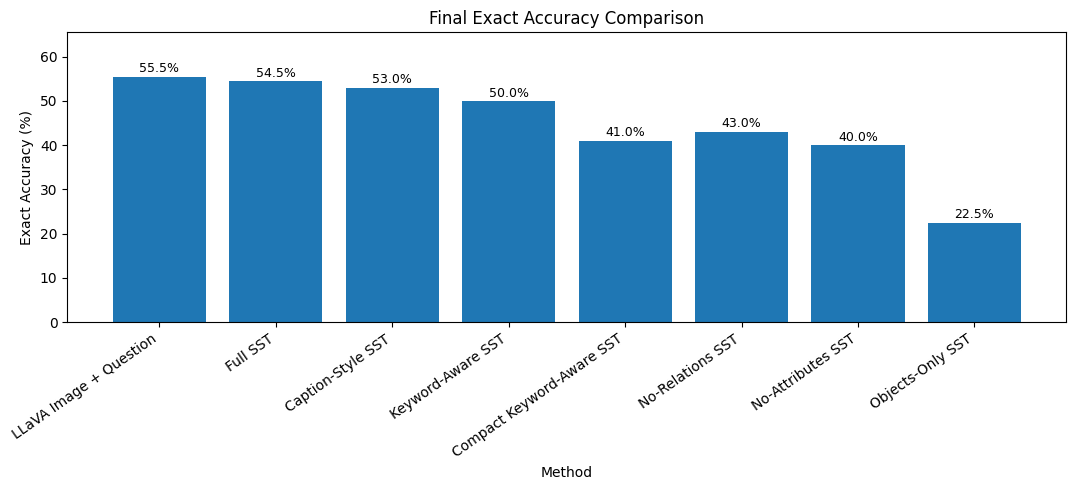

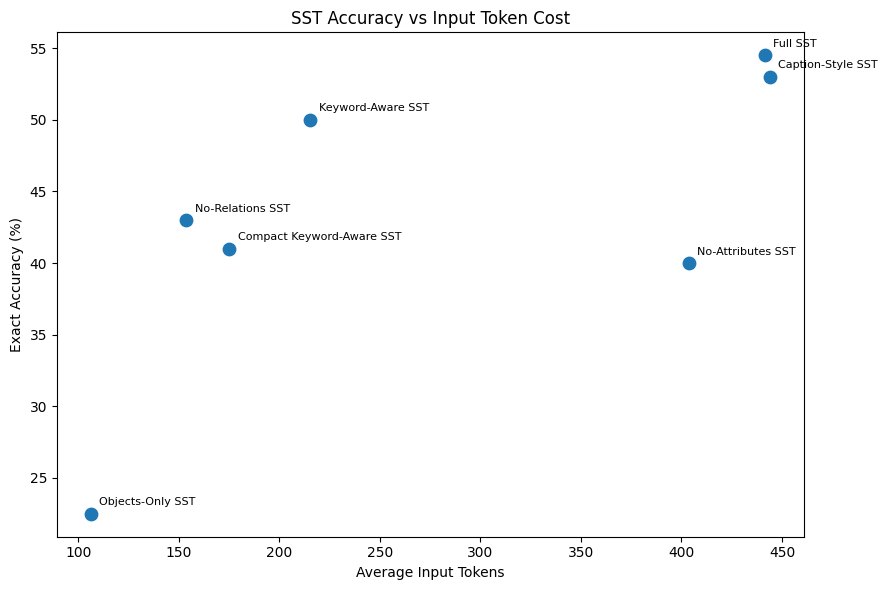

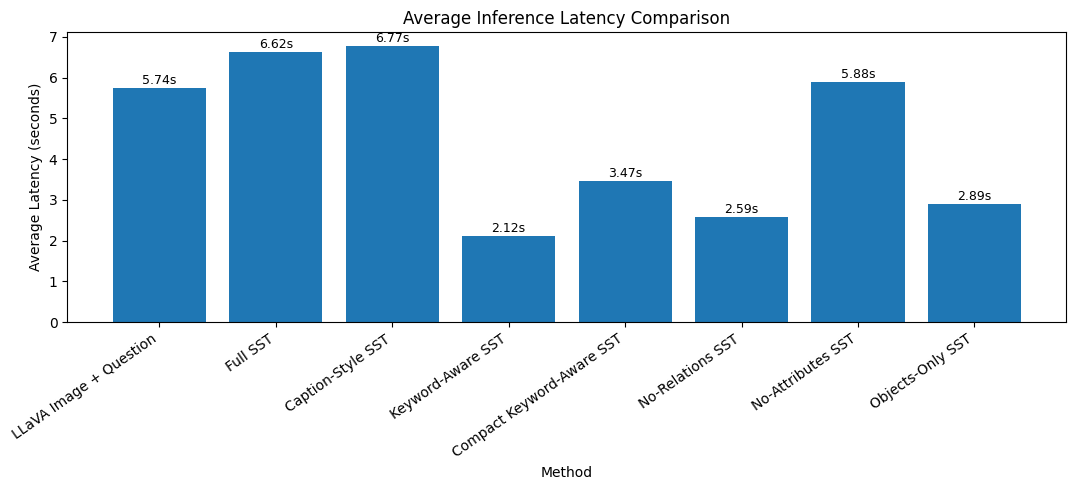

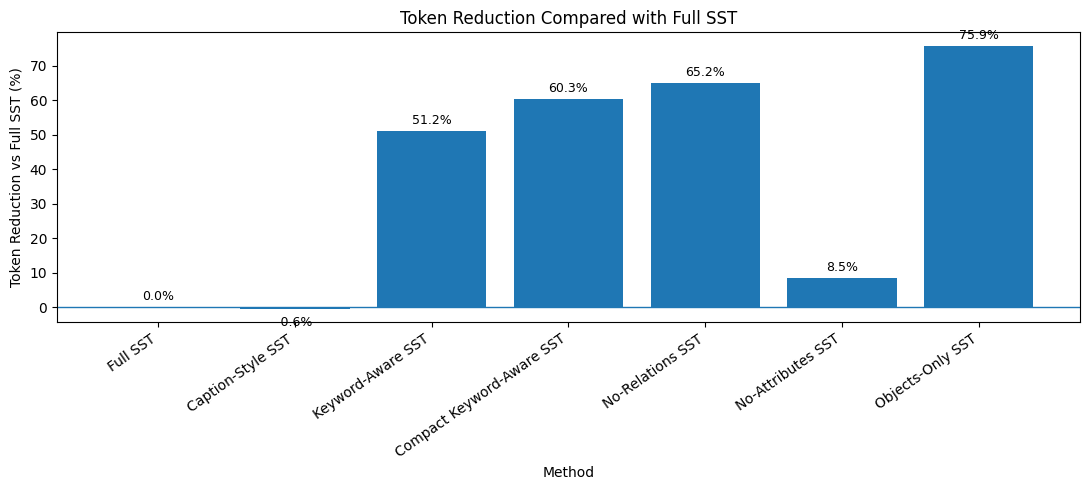


Saved final figures:
- /Users/alisha/Documents/CSE427_SST_Project/outputs/figures/final_exact_accuracy_comparison.png
- /Users/alisha/Documents/CSE427_SST_Project/outputs/figures/sst_accuracy_vs_tokens.png
- /Users/alisha/Documents/CSE427_SST_Project/outputs/figures/final_latency_comparison.png
- /Users/alisha/Documents/CSE427_SST_Project/outputs/figures/sst_token_reduction.png


In [2]:
# Step 2: Generate final report figures from existing results only
# This cell does NOT rerun Mistral or LLaVA.
# It only reads final_sst_vs_llava_comparison.csv and saves clean figures.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# Locate results directory safely
# ----------------------------
candidate_dirs = [
    Path("../outputs/results"),
    Path("outputs/results")
]

RESULTS_DIR = next((p for p in candidate_dirs if (p / "final_sst_vs_llava_comparison.csv").exists()), None)

if RESULTS_DIR is None:
    print("Current working directory:", Path.cwd())
    raise FileNotFoundError("Could not find final_sst_vs_llava_comparison.csv in expected results folders.")

FIG_DIR = RESULTS_DIR.parent / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

comparison_path = RESULTS_DIR / "final_sst_vs_llava_comparison.csv"
df = pd.read_csv(comparison_path)

print("Loaded:")
print(comparison_path.resolve())

# ----------------------------
# Clean numeric columns
# ----------------------------
numeric_cols = [
    "exact_accuracy_pct",
    "lenient_accuracy_pct",
    "avg_input_tokens",
    "token_reduction_vs_full_sst_pct",
    "avg_latency_sec"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ----------------------------
# Figure 1: Exact accuracy comparison
# ----------------------------
fig, ax = plt.subplots(figsize=(11, 5))

plot_df = df.copy()
ax.bar(plot_df["method"], plot_df["exact_accuracy_pct"])

ax.set_title("Final Exact Accuracy Comparison")
ax.set_ylabel("Exact Accuracy (%)")
ax.set_xlabel("Method")
ax.set_ylim(0, max(plot_df["exact_accuracy_pct"].dropna()) + 10)

for i, value in enumerate(plot_df["exact_accuracy_pct"]):
    if not pd.isna(value):
        ax.text(i, value + 1, f"{value:.1f}%", ha="center", fontsize=9)

plt.xticks(rotation=35, ha="right")
plt.tight_layout()

fig1_path = FIG_DIR / "final_exact_accuracy_comparison.png"
plt.savefig(fig1_path, dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# Figure 2: SST token-efficiency tradeoff
# Only SST methods have token counts.
# ----------------------------
sst_df = df[df["input_type"] == "Oracle SST text"].copy()

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(sst_df["avg_input_tokens"], sst_df["exact_accuracy_pct"], s=80)

for _, row in sst_df.iterrows():
    ax.annotate(
        row["method"],
        (row["avg_input_tokens"], row["exact_accuracy_pct"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8
    )

ax.set_title("SST Accuracy vs Input Token Cost")
ax.set_xlabel("Average Input Tokens")
ax.set_ylabel("Exact Accuracy (%)")

plt.tight_layout()

fig2_path = FIG_DIR / "sst_accuracy_vs_tokens.png"
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# Figure 3: Latency comparison
# ----------------------------
latency_df = df.dropna(subset=["avg_latency_sec"]).copy()

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(latency_df["method"], latency_df["avg_latency_sec"])

ax.set_title("Average Inference Latency Comparison")
ax.set_ylabel("Average Latency (seconds)")
ax.set_xlabel("Method")

for i, value in enumerate(latency_df["avg_latency_sec"]):
    ax.text(i, value + 0.1, f"{value:.2f}s", ha="center", fontsize=9)

plt.xticks(rotation=35, ha="right")
plt.tight_layout()

fig3_path = FIG_DIR / "final_latency_comparison.png"
plt.savefig(fig3_path, dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# Figure 4: Token reduction for SST methods
# ----------------------------
token_df = sst_df.copy()

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(token_df["method"], token_df["token_reduction_vs_full_sst_pct"])

ax.set_title("Token Reduction Compared with Full SST")
ax.set_ylabel("Token Reduction vs Full SST (%)")
ax.set_xlabel("Method")
ax.axhline(0, linewidth=1)

for i, value in enumerate(token_df["token_reduction_vs_full_sst_pct"]):
    if not pd.isna(value):
        label_y = value + 2 if value >= 0 else value - 5
        ax.text(i, label_y, f"{value:.1f}%", ha="center", fontsize=9)

plt.xticks(rotation=35, ha="right")
plt.tight_layout()

fig4_path = FIG_DIR / "sst_token_reduction.png"
plt.savefig(fig4_path, dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# Final saved file report
# ----------------------------
print("\nSaved final figures:")
for path in [fig1_path, fig2_path, fig3_path, fig4_path]:
    print("-", path.resolve())

In [3]:
# Step 3: Create final Results + Discussion draft from existing results
# This cell does NOT rerun any model.
# It writes a clean markdown section for the final report/paper.

from pathlib import Path
import pandas as pd
import numpy as np

# ----------------------------
# Locate project folders
# ----------------------------
candidate_results_dirs = [
    Path("../outputs/results"),
    Path("outputs/results")
]

RESULTS_DIR = next(
    (p for p in candidate_results_dirs if (p / "final_sst_vs_llava_comparison.csv").exists()),
    None
)

if RESULTS_DIR is None:
    raise FileNotFoundError("Could not find final_sst_vs_llava_comparison.csv.")

# Put draft inside paper/ if available
candidate_paper_dirs = [
    Path("../paper"),
    Path("paper")
]

PAPER_DIR = next((p for p in candidate_paper_dirs if p.exists()), Path("../paper"))
PAPER_DIR.mkdir(parents=True, exist_ok=True)

comparison_path = RESULTS_DIR / "final_sst_vs_llava_comparison.csv"
df = pd.read_csv(comparison_path)

print("Loaded final comparison table:")
print(comparison_path.resolve())

# ----------------------------
# Helper functions
# ----------------------------
def get_row(method_name):
    match = df[df["method"] == method_name]
    if len(match) == 0:
        raise ValueError(f"Missing method in comparison table: {method_name}")
    return match.iloc[0]

def fmt(x, digits=2):
    if pd.isna(x):
        return "N/A"
    return f"{float(x):.{digits}f}"

llava = get_row("LLaVA Image + Question")
full = get_row("Full SST")
caption = get_row("Caption-Style SST")
keyword = get_row("Keyword-Aware SST")
compact = get_row("Compact Keyword-Aware SST")
no_rel = get_row("No-Relations SST")
no_attr = get_row("No-Attributes SST")
objects = get_row("Objects-Only SST")

# ----------------------------
# Draft text
# ----------------------------
draft = f"""# Results and Discussion Draft

## Experimental Setup

The final evaluation was conducted on a balanced 200-sample subset of the GQA validation split. The project compares two main reasoning settings. The first is a direct vision-language baseline, where LLaVA receives the raw image and question. The second is an oracle Scene-to-Structured-Text (SST) setting, where GQA scene graphs are converted into structured text containing objects, counts, attributes, relations, and text/OCR-like entries, and Mistral answers the question using only this structured representation.

This distinction is important: the SST branch does not yet implement a fully automatic raw image-to-SST pipeline. Instead, it evaluates whether compact structured semantic representations can preserve visual reasoning accuracy when high-quality scene graph information is already available. Therefore, the current SST results should be interpreted as an oracle semantic-compression study rather than a complete deployable vision pipeline.

## Main Accuracy Results

The direct LLaVA image-question baseline achieved {fmt(llava["exact_accuracy_pct"], 1)}% exact accuracy and {fmt(llava["lenient_accuracy_pct"], 1)}% lenient accuracy. Full SST with Mistral achieved {fmt(full["exact_accuracy_pct"], 1)}% exact accuracy and {fmt(full["lenient_accuracy_pct"], 1)}% lenient accuracy. This shows that the oracle SST representation is competitive with the direct local VLM baseline on this 200-sample GQA subset.

The strongest compressed SST method was Keyword-Aware SST. It achieved {fmt(keyword["exact_accuracy_pct"], 1)}% exact accuracy and {fmt(keyword["lenient_accuracy_pct"], 1)}% lenient accuracy while reducing average input tokens from {fmt(full["avg_input_tokens"], 2)} to {fmt(keyword["avg_input_tokens"], 2)}. This corresponds to a {fmt(keyword["token_reduction_vs_full_sst_pct"], 2)}% token reduction compared with Full SST. The exact accuracy drop from Full SST was {fmt(float(full["exact_accuracy_pct"]) - float(keyword["exact_accuracy_pct"]), 1)} percentage points, while the lenient accuracy drop was only {fmt(float(full["lenient_accuracy_pct"]) - float(keyword["lenient_accuracy_pct"]), 1)} percentage points.

Caption-Style SST achieved {fmt(caption["exact_accuracy_pct"], 1)}% exact accuracy and {fmt(caption["lenient_accuracy_pct"], 1)}% lenient accuracy, which is close to Full SST. However, it did not reduce token usage; its average token count was {fmt(caption["avg_input_tokens"], 2)}, slightly higher than Full SST. This suggests that converting structured SST into prose can preserve readability, but it does not provide the desired compression benefit.

## Token-Efficiency Tradeoff

The main contribution of the project is the accuracy-compression tradeoff demonstrated by Keyword-Aware SST. Full SST achieved the highest SST exact accuracy, but required {fmt(full["avg_input_tokens"], 2)} average input tokens. Keyword-Aware SST reduced this to {fmt(keyword["avg_input_tokens"], 2)} average tokens while preserving most of the reasoning performance.

More aggressive compression produced larger token reductions but caused clear accuracy degradation. Compact Keyword-Aware SST reduced tokens by {fmt(compact["token_reduction_vs_full_sst_pct"], 2)}%, but exact accuracy dropped to {fmt(compact["exact_accuracy_pct"], 1)}%. Objects-Only SST achieved the largest token reduction at {fmt(objects["token_reduction_vs_full_sst_pct"], 2)}%, but exact accuracy collapsed to {fmt(objects["exact_accuracy_pct"], 1)}%. This confirms that object lists alone are not sufficient for many GQA-style reasoning questions; attributes, relations, and readable structure are important.

## Ablation Analysis

The ablation results show which SST components are most important. Removing relations reduced exact accuracy to {fmt(no_rel["exact_accuracy_pct"], 1)}%, and removing attributes reduced exact accuracy to {fmt(no_attr["exact_accuracy_pct"], 1)}%. Objects-Only SST performed worst, reaching only {fmt(objects["exact_accuracy_pct"], 1)}% exact accuracy. These results support the claim that the benefit of SST comes not merely from naming visible objects, but from preserving structured semantic evidence such as attributes and relationships.

The No-Attributes result is especially informative because it retained a relatively high token count of {fmt(no_attr["avg_input_tokens"], 2)} tokens but still performed poorly. This indicates that accuracy is not determined only by prompt length; the type and relevance of retained semantic information matter.

## Latency Results

Latency was measured on the local hardware used for the experiment, so it should be interpreted as system-dependent rather than as a universal property of the models. LLaVA averaged {fmt(llava["avg_latency_sec"], 2)} seconds per query. Full SST with Mistral averaged {fmt(full["avg_latency_sec"], 2)} seconds, while Keyword-Aware SST averaged {fmt(keyword["avg_latency_sec"], 2)} seconds. This suggests that reducing SST prompt length can also reduce local inference time, although latency depends on hardware, model loading, Ollama runtime behavior, and prompt length.

## Comparison with Direct VLM Baseline

LLaVA slightly outperformed Full SST in exact accuracy, with {fmt(llava["exact_accuracy_pct"], 1)}% compared with {fmt(full["exact_accuracy_pct"], 1)}%. However, Full SST achieved higher lenient accuracy, with {fmt(full["lenient_accuracy_pct"], 1)}% compared with LLaVA's {fmt(llava["lenient_accuracy_pct"], 1)}%. These results should not be interpreted as SST replacing direct VLMs. Instead, they show that structured semantic text can be competitive for GQA-style reasoning when high-quality scene graph information is available.

The comparison also has an important measurement limitation: text token counts are meaningful for SST prompts, but the raw image input used by LLaVA is not directly comparable using the same text-token metric. Therefore, the strongest token-efficiency claim should be made within the SST family, especially Full SST versus Keyword-Aware SST.

## Key Finding

The main finding is that Keyword-Aware SST provides the best balance between compression and reasoning performance. On the 200-sample balanced GQA subset, it reduced average input tokens by {fmt(keyword["token_reduction_vs_full_sst_pct"], 2)}% compared with Full SST while retaining most of the accuracy. More aggressive compression methods reduced token usage further but caused substantially larger accuracy drops. This supports the hypothesis that question-aware semantic filtering can remove irrelevant scene information while preserving much of the evidence needed for visual reasoning.

## Limitations

The most important limitation is that the SST pipeline currently uses GQA scene graphs as input. This makes the SST branch an oracle semantic-compression evaluation. A real deployed system would require automatic image-to-SST extraction using object detection, OCR, attribute recognition, and relation extraction. Errors in those extraction stages would likely reduce downstream reasoning accuracy.

The evaluation is also limited to 200 balanced validation examples. This is appropriate for a course-scale local-model experiment, but a stronger research paper would require evaluation on a larger subset and possibly multiple random seeds or multiple balanced splits. The models were also run locally through Ollama, so performance and latency may differ across machines.

Finally, answer normalization affects exact and lenient accuracy. Some model outputs may be semantically correct but phrased differently from the ground-truth answer. This is why both exact and lenient accuracy are reported.

## Final Claim

In an oracle-SST evaluation on 200 balanced GQA validation examples, Keyword-Aware SST reduced average input tokens by {fmt(keyword["token_reduction_vs_full_sst_pct"], 2)}% compared with Full SST while preserving most reasoning accuracy. Its exact accuracy was {fmt(keyword["exact_accuracy_pct"], 1)}%, compared with {fmt(full["exact_accuracy_pct"], 1)}% for Full SST and {fmt(llava["exact_accuracy_pct"], 1)}% for the direct LLaVA image-question baseline. The ablation results show that over-compression and removal of key semantic components substantially harm accuracy, indicating that structured attributes, relations, and readable semantic organization are important for visual reasoning.
"""

# ----------------------------
# Save draft
# ----------------------------
draft_path = PAPER_DIR / "results_and_discussion_draft.md"

with open(draft_path, "w") as f:
    f.write(draft)

print("\nSaved Results + Discussion draft:")
print(draft_path.resolve())

print("\nPreview:")
print(draft[:2500])

Loaded final comparison table:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_sst_vs_llava_comparison.csv

Saved Results + Discussion draft:
/Users/alisha/Documents/CSE427_SST_Project/paper/results_and_discussion_draft.md

Preview:
# Results and Discussion Draft

## Experimental Setup

The final evaluation was conducted on a balanced 200-sample subset of the GQA validation split. The project compares two main reasoning settings. The first is a direct vision-language baseline, where LLaVA receives the raw image and question. The second is an oracle Scene-to-Structured-Text (SST) setting, where GQA scene graphs are converted into structured text containing objects, counts, attributes, relations, and text/OCR-like entries, and Mistral answers the question using only this structured representation.

This distinction is important: the SST branch does not yet implement a fully automatic raw image-to-SST pipeline. Instead, it evaluates whether compact structured semantic rep

Saving pipeline figure to:
/Users/alisha/Documents/CSE427_SST_Project/src/pipelines/sst_multimodal_pipeline.png
/Users/alisha/Documents/CSE427_SST_Project/src/pipelines/sst_multimodal_pipeline.pdf


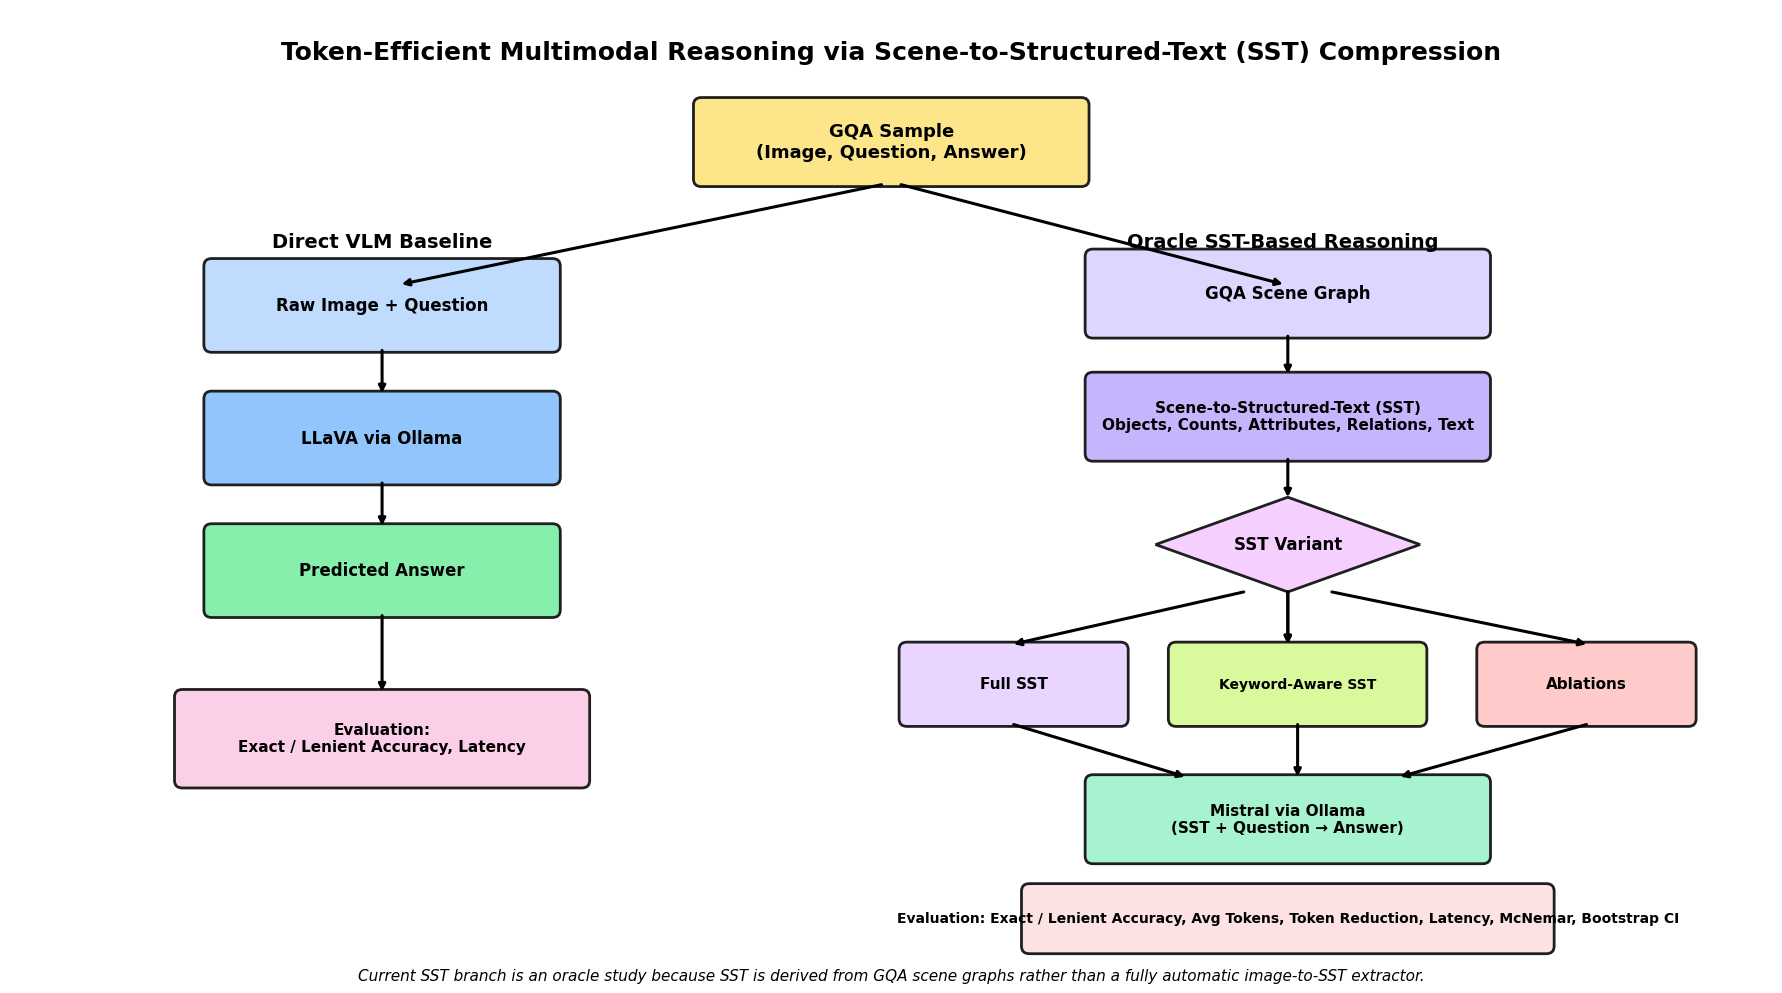


Saved successfully:
- /Users/alisha/Documents/CSE427_SST_Project/src/pipelines/sst_multimodal_pipeline.png
- /Users/alisha/Documents/CSE427_SST_Project/src/pipelines/sst_multimodal_pipeline.pdf


In [4]:
# Step: Create a clean pipeline diagram and save it into src/pipelines
# This does NOT modify model code or experiment outputs.
# It only creates a high-quality pipeline figure for your report/paper.

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon

# ----------------------------
# Find/save paths safely
# ----------------------------
candidate_project_roots = [Path(".."), Path(".")]
PROJECT_ROOT = None

for p in candidate_project_roots:
    if (p / "src").exists() and (p / "notebooks").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path("..")

PIPELINE_DIR = PROJECT_ROOT / "src" / "pipelines"
PIPELINE_DIR.mkdir(parents=True, exist_ok=True)

png_path = PIPELINE_DIR / "sst_multimodal_pipeline.png"
pdf_path = PIPELINE_DIR / "sst_multimodal_pipeline.pdf"

print("Saving pipeline figure to:")
print(png_path.resolve())
print(pdf_path.resolve())

# ----------------------------
# Helper drawing functions
# ----------------------------
def draw_box(ax, x, y, w, h, text, fc="#E8F0FE", ec="#1F1F1F", fontsize=12, lw=2.0, roundness=0.08):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle=f"round,pad=0.02,rounding_size={roundness}",
        linewidth=lw, edgecolor=ec, facecolor=fc
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize, weight="bold")
    return box

def draw_diamond(ax, x, y, w, h, text, fc="#F3E8FF", ec="#1F1F1F", fontsize=12, lw=2.0):
    pts = [
        (x + w/2, y + h),
        (x + w, y + h/2),
        (x + w/2, y),
        (x, y + h/2)
    ]
    diamond = Polygon(pts, closed=True, facecolor=fc, edgecolor=ec, linewidth=lw)
    ax.add_patch(diamond)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize, weight="bold")
    return diamond

def arrow(ax, x1, y1, x2, y2, lw=2.2):
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-|>", lw=lw, shrinkA=0, shrinkB=0)
    )

# ----------------------------
# Figure canvas
# ----------------------------
fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 18)
ax.set_ylim(0, 10)
ax.axis("off")

# ----------------------------
# Title
# ----------------------------
ax.text(
    9, 9.55,
    "Token-Efficient Multimodal Reasoning via Scene-to-Structured-Text (SST) Compression",
    ha="center", va="center", fontsize=18, weight="bold"
)

# ----------------------------
# Common input
# ----------------------------
draw_box(ax, 7.0, 8.15, 4.0, 0.9, "GQA Sample\n(Image, Question, Answer)", fc="#FDE68A", fontsize=13)

# Branch labels
ax.text(3.8, 7.55, "Direct VLM Baseline", ha="center", va="center", fontsize=14, weight="bold")
ax.text(13.0, 7.55, "Oracle SST-Based Reasoning", ha="center", va="center", fontsize=14, weight="bold")

# Split arrows
arrow(ax, 8.9, 8.15, 4.0, 7.1)
arrow(ax, 9.1, 8.15, 13.0, 7.1)

# ----------------------------
# Left branch: LLaVA baseline
# ----------------------------
draw_box(ax, 2.0, 6.4, 3.6, 0.95, "Raw Image + Question", fc="#BFDBFE", fontsize=12)
draw_box(ax, 2.0, 5.0, 3.6, 0.95, "LLaVA via Ollama", fc="#93C5FD", fontsize=12)
draw_box(ax, 2.0, 3.6, 3.6, 0.95, "Predicted Answer", fc="#86EFAC", fontsize=12)
draw_box(ax, 1.7, 1.8, 4.2, 1.0, "Evaluation:\nExact / Lenient Accuracy, Latency", fc="#FBCFE8", fontsize=11)

arrow(ax, 3.8, 6.4, 3.8, 5.95)
arrow(ax, 3.8, 5.0, 3.8, 4.55)
arrow(ax, 3.8, 3.6, 3.8, 2.8)

# ----------------------------
# Right branch: SST pipeline
# ----------------------------
draw_box(ax, 11.0, 6.55, 4.1, 0.9, "GQA Scene Graph", fc="#DDD6FE", fontsize=12)
draw_box(ax, 11.0, 5.25, 4.1, 0.9, "Scene-to-Structured-Text (SST)\nObjects, Counts, Attributes, Relations, Text", fc="#C4B5FD", fontsize=11)
draw_diamond(ax, 11.7, 3.85, 2.7, 1.0, "SST Variant", fc="#F5D0FE", fontsize=12)

# Variant boxes
draw_box(ax, 9.1, 2.45, 2.3, 0.85, "Full SST", fc="#E9D5FF", fontsize=11)
draw_box(ax, 11.85, 2.45, 2.6, 0.85, "Keyword-Aware SST", fc="#D9F99D", fontsize=10)
draw_box(ax, 15.0, 2.45, 2.2, 0.85, "Ablations", fc="#FECACA", fontsize=11)

draw_box(ax, 11.0, 1.0, 4.1, 0.9, "Mistral via Ollama\n(SST + Question → Answer)", fc="#A7F3D0", fontsize=11)

# arrows in SST branch
arrow(ax, 13.05, 6.55, 13.05, 6.15)
arrow(ax, 13.05, 5.25, 13.05, 4.85)
arrow(ax, 13.05, 3.85, 13.05, 3.3)

# fan-out from variant
arrow(ax, 12.6, 3.85, 10.25, 3.3)
arrow(ax, 13.05, 3.85, 13.05, 3.3)
arrow(ax, 13.5, 3.85, 16.1, 3.3)

# from variants to final reasoning
arrow(ax, 10.25, 2.45, 12.0, 1.9)
arrow(ax, 13.15, 2.45, 13.15, 1.9)
arrow(ax, 16.1, 2.45, 14.2, 1.9)

# Evaluation box for SST
draw_box(ax, 10.35, 0.05, 5.4, 0.7,
         "Evaluation: Exact / Lenient Accuracy, Avg Tokens, Token Reduction, Latency, McNemar, Bootstrap CI",
         fc="#FDE2E4", fontsize=10)

# ----------------------------
# Notes / legend
# ----------------------------
ax.text(
    9, -0.2,
    "Current SST branch is an oracle study because SST is derived from GQA scene graphs rather than a fully automatic image-to-SST extractor.",
    ha="center", va="center", fontsize=11, style="italic"
)

# ----------------------------
# Save outputs
# ----------------------------
plt.tight_layout()
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("\nSaved successfully:")
print("-", png_path.resolve())
print("-", pdf_path.resolve())

In [5]:
# Step 4: Create presentable evaluation metrics tables and IEEE-ready metrics text
# This does NOT rerun any model.
# It only derives extra metrics from the final comparison CSV.

from pathlib import Path
import pandas as pd
import numpy as np

# ----------------------------
# Locate final comparison table
# ----------------------------
candidate_results_dirs = [
    Path("../outputs/results"),
    Path("outputs/results")
]

RESULTS_DIR = next(
    (p for p in candidate_results_dirs if (p / "final_sst_vs_llava_comparison.csv").exists()),
    None
)

if RESULTS_DIR is None:
    raise FileNotFoundError("Could not find final_sst_vs_llava_comparison.csv.")

candidate_paper_dirs = [
    Path("../paper"),
    Path("paper")
]

PAPER_DIR = next((p for p in candidate_paper_dirs if p.exists()), Path("../paper"))
PAPER_DIR.mkdir(parents=True, exist_ok=True)

comparison_path = RESULTS_DIR / "final_sst_vs_llava_comparison.csv"
df = pd.read_csv(comparison_path)

print("Loaded final comparison table:")
print(comparison_path.resolve())

# ----------------------------
# Clean numeric columns
# ----------------------------
numeric_cols = [
    "n",
    "exact_accuracy_pct",
    "lenient_accuracy_pct",
    "avg_input_tokens",
    "token_reduction_vs_full_sst_pct",
    "avg_latency_sec"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ----------------------------
# Reference rows
# ----------------------------
full_row = df[df["method"] == "Full SST"].iloc[0]
llava_row = df[df["method"] == "LLaVA Image + Question"].iloc[0]

full_exact = float(full_row["exact_accuracy_pct"])
llava_exact = float(llava_row["exact_accuracy_pct"])
full_tokens = float(full_row["avg_input_tokens"])
full_latency = float(full_row["avg_latency_sec"])

# ----------------------------
# Add derived metrics
# ----------------------------
metrics_df = df.copy()

metrics_df["exact_correct_count"] = (
    metrics_df["n"] * metrics_df["exact_accuracy_pct"] / 100
).round().astype("Int64")

metrics_df["lenient_correct_count"] = (
    metrics_df["n"] * metrics_df["lenient_accuracy_pct"] / 100
).round().astype("Int64")

metrics_df["exact_error_pct"] = 100 - metrics_df["exact_accuracy_pct"]

metrics_df["accuracy_delta_vs_full_sst_pp"] = (
    metrics_df["exact_accuracy_pct"] - full_exact
).round(2)

metrics_df["accuracy_delta_vs_llava_pp"] = (
    metrics_df["exact_accuracy_pct"] - llava_exact
).round(2)

metrics_df["tokens_saved_vs_full_sst"] = (
    full_tokens - metrics_df["avg_input_tokens"]
).round(2)

metrics_df.loc[
    metrics_df["avg_input_tokens"].isna(), 
    "tokens_saved_vs_full_sst"
] = np.nan

metrics_df["latency_speedup_vs_full_sst_x"] = (
    full_latency / metrics_df["avg_latency_sec"]
).round(2)

metrics_df["correct_answers_per_1000_input_tokens"] = (
    (metrics_df["exact_accuracy_pct"] / 100) * 1000 / metrics_df["avg_input_tokens"]
).round(3)

metrics_df.loc[
    metrics_df["avg_input_tokens"].isna(),
    "correct_answers_per_1000_input_tokens"
] = np.nan

# ----------------------------
# Add short report interpretation
# ----------------------------
def interpret_method(row):
    method = row["method"]

    if method == "LLaVA Image + Question":
        return "Direct VLM baseline"
    if method == "Full SST":
        return "Oracle SST reference"
    if method == "Keyword-Aware SST":
        return "Best compression-accuracy tradeoff"
    if method == "Caption-Style SST":
        return "Readable but not token-efficient"
    if method == "Compact Keyword-Aware SST":
        return "Over-compressed; accuracy drops"
    if method == "Objects-Only SST":
        return "Too little semantic evidence"
    if method == "No-Relations SST":
        return "Tests importance of relations"
    if method == "No-Attributes SST":
        return "Tests importance of attributes"
    return "Ablation"

metrics_df["report_interpretation"] = metrics_df.apply(interpret_method, axis=1)

# ----------------------------
# Make clean presentable table
# ----------------------------
presentable_cols = [
    "method",
    "input_type",
    "reasoning_model",
    "n",
    "exact_accuracy_pct",
    "lenient_accuracy_pct",
    "exact_correct_count",
    "lenient_correct_count",
    "avg_input_tokens",
    "token_reduction_vs_full_sst_pct",
    "tokens_saved_vs_full_sst",
    "avg_latency_sec",
    "latency_speedup_vs_full_sst_x",
    "accuracy_delta_vs_full_sst_pp",
    "accuracy_delta_vs_llava_pp",
    "correct_answers_per_1000_input_tokens",
    "report_interpretation"
]

presentable_df = metrics_df[presentable_cols].copy()

rename_map = {
    "method": "Method",
    "input_type": "Input Type",
    "reasoning_model": "Reasoning Model",
    "n": "N",
    "exact_accuracy_pct": "Exact Accuracy (%)",
    "lenient_accuracy_pct": "Lenient Accuracy (%)",
    "exact_correct_count": "Exact Correct",
    "lenient_correct_count": "Lenient Correct",
    "avg_input_tokens": "Avg Input Tokens",
    "token_reduction_vs_full_sst_pct": "Token Reduction vs Full SST (%)",
    "tokens_saved_vs_full_sst": "Tokens Saved vs Full SST",
    "avg_latency_sec": "Avg Latency (s)",
    "latency_speedup_vs_full_sst_x": "Latency Speedup vs Full SST (x)",
    "accuracy_delta_vs_full_sst_pp": "Exact Accuracy Δ vs Full SST (pp)",
    "accuracy_delta_vs_llava_pp": "Exact Accuracy Δ vs LLaVA (pp)",
    "correct_answers_per_1000_input_tokens": "Exact Correct per 1000 Tokens",
    "report_interpretation": "Interpretation"
}

presentable_df = presentable_df.rename(columns=rename_map)

# ----------------------------
# Save CSV and Markdown
# ----------------------------
metrics_csv_path = RESULTS_DIR / "final_presentable_evaluation_metrics.csv"
metrics_md_path = RESULTS_DIR / "final_presentable_evaluation_metrics.md"

presentable_df.to_csv(metrics_csv_path, index=False)

def df_to_markdown_no_tabulate(df):
    df_str = df.fillna("").astype(str)
    header = "| " + " | ".join(df_str.columns) + " |"
    separator = "| " + " | ".join(["---"] * len(df_str.columns)) + " |"
    rows = []
    for _, row in df_str.iterrows():
        rows.append("| " + " | ".join(row.values) + " |")
    return "\n".join([header, separator] + rows)

with open(metrics_md_path, "w") as f:
    f.write(df_to_markdown_no_tabulate(presentable_df))

# ----------------------------
# IEEE-ready Evaluation Metrics subsection
# ----------------------------
metrics_text = """## Evaluation Metrics

The final experiments are evaluated using both task-performance and efficiency metrics. Exact accuracy measures the percentage of predictions that exactly match the normalized ground-truth answer. Lenient accuracy allows minor acceptable answer-format variations after normalization, which is useful because generative models may produce semantically correct answers with slightly different wording.

For efficiency, average input tokens are reported for all SST-based methods. Token reduction is computed relative to Full SST as:

Token Reduction (%) = ((Tokens_Full_SST - Tokens_Method) / Tokens_Full_SST) × 100

Average latency measures the mean inference time per question in seconds on the local experimental machine. Since latency depends on local hardware and Ollama runtime behavior, it is reported as an implementation-level efficiency measure rather than a universal model property.

Additional derived metrics are included for interpretability. Exact correct count and lenient correct count show how many of the 200 questions were answered correctly. Accuracy delta versus Full SST shows how much performance is lost or gained compared with the oracle SST reference. Accuracy delta versus LLaVA compares each method against the direct image-question VLM baseline. Tokens saved versus Full SST and correct answers per 1000 input tokens summarize the compression-efficiency tradeoff among SST methods.

For statistical reliability, the project also reports bootstrap confidence intervals and McNemar-style paired comparisons where available. These paired comparisons are important because all methods are evaluated on the same 200 examples.
"""

metrics_text_path = PAPER_DIR / "evaluation_metrics_section.md"

with open(metrics_text_path, "w") as f:
    f.write(metrics_text)

# ----------------------------
# Display final output
# ----------------------------
print("\nSaved presentable metrics CSV:")
print(metrics_csv_path.resolve())

print("\nSaved presentable metrics Markdown:")
print(metrics_md_path.resolve())

print("\nSaved IEEE-ready metrics text:")
print(metrics_text_path.resolve())

print("\nPresentable evaluation metrics table:")
display(presentable_df)

Loaded final comparison table:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_sst_vs_llava_comparison.csv

Saved presentable metrics CSV:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_presentable_evaluation_metrics.csv

Saved presentable metrics Markdown:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_presentable_evaluation_metrics.md

Saved IEEE-ready metrics text:
/Users/alisha/Documents/CSE427_SST_Project/paper/evaluation_metrics_section.md

Presentable evaluation metrics table:


,Method,Input Type,Reasoning Model,N,Exact Accuracy (%),Lenient Accuracy (%),Exact Correct,Lenient Correct,Avg Input Tokens,Token Reduction vs Full SST (%),Tokens Saved vs Full SST,Avg Latency (s),Latency Speedup vs Full SST (x),Exact Accuracy Δ vs Full SST (pp),Exact Accuracy Δ vs LLaVA (pp),Exact Correct per 1000 Tokens,Interpretation
0,LLaVA Image + Question,Raw image + question,LLaVA via Ollama,200,55.5,56.5,111,113,NaN,NaN,NaN,5.74,1.15,1.0,0.0,NaN,Direct VLM baseline
1,Full SST,Oracle SST text,Mistral via Ollama,200,54.5,58.5,109,117,441.44,0.00,0.00,6.62,1.00,0.0,-1.0,1.235,Oracle SST reference
2,Caption-Style SST,Oracle SST text,Mistral via Ollama,200,53.0,58.5,106,117,443.96,-0.57,-2.52,6.77,0.98,-1.5,-2.5,1.194,Readable but not token-efficient
3,Keyword-Aware SST,Oracle SST text,Mistral via Ollama,200,50.0,57.0,100,114,215.53,51.18,225.91,2.12,3.12,-4.5,-5.5,2.320,Best compression-accuracy tradeoff
4,Compact Keyword-Aware SST,Oracle SST text,Mistral via Ollama,200,41.0,52.0,82,104,175.10,60.33,266.34,3.47,1.91,-13.5,-14.5,2.342,Over-compressed; accuracy drops
5,No-Relations SST,Oracle SST text,Mistral via Ollama,200,43.0,43.0,86,86,153.79,65.16,287.65,2.59,2.56,-11.5,-12.5,2.796,Tests importance of relations
6,No-Attributes SST,Oracle SST text,Mistral via Ollama,200,40.0,43.0,80,86,403.84,8.52,37.60,5.88,1.13,-14.5,-15.5,0.990,Tests importance of attributes
7,Objects-Only SST,Oracle SST text,Mistral via Ollama,200,22.5,24.0,45,48,106.24,75.93,335.20,2.89,2.29,-32.0,-33.0,2.118,Too little semantic evidence


In [6]:
# Step 5: Create compact IEEE-ready evaluation table
# This does NOT rerun experiments.
# It only creates a shorter table suitable for the IEEE report.

from pathlib import Path
import pandas as pd
import numpy as np

candidate_results_dirs = [
    Path("../outputs/results"),
    Path("outputs/results")
]

RESULTS_DIR = next(
    (p for p in candidate_results_dirs if (p / "final_presentable_evaluation_metrics.csv").exists()),
    None
)

if RESULTS_DIR is None:
    raise FileNotFoundError("Could not find final_presentable_evaluation_metrics.csv.")

candidate_paper_dirs = [
    Path("../paper"),
    Path("paper")
]

PAPER_DIR = next((p for p in candidate_paper_dirs if p.exists()), Path("../paper"))
PAPER_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = RESULTS_DIR / "final_presentable_evaluation_metrics.csv"
df = pd.read_csv(metrics_path)

print("Loaded:")
print(metrics_path.resolve())

# Compact IEEE-style table
compact_cols = [
    "Method",
    "Exact Accuracy (%)",
    "Lenient Accuracy (%)",
    "Exact Correct",
    "Avg Input Tokens",
    "Token Reduction vs Full SST (%)",
    "Avg Latency (s)",
    "Exact Accuracy Δ vs Full SST (pp)"
]

compact_df = df[compact_cols].copy()

# Rename for paper readability
compact_df = compact_df.rename(columns={
    "Exact Accuracy (%)": "Exact Acc. (%)",
    "Lenient Accuracy (%)": "Lenient Acc. (%)",
    "Exact Correct": "Correct / 200",
    "Avg Input Tokens": "Avg Tokens",
    "Token Reduction vs Full SST (%)": "Token Red. (%)",
    "Avg Latency (s)": "Latency (s)",
    "Exact Accuracy Δ vs Full SST (pp)": "Δ vs Full SST"
})

# Make Correct / 200 clearer
compact_df["Correct / 200"] = compact_df["Correct / 200"].astype(str) + "/200"

# Replace NaN with dash for LLaVA token fields
compact_df = compact_df.fillna("—")

# Save CSV
compact_csv_path = RESULTS_DIR / "ieee_compact_evaluation_table.csv"
compact_df.to_csv(compact_csv_path, index=False)

# Save Markdown
def df_to_markdown_no_tabulate(df):
    df_str = df.astype(str)
    header = "| " + " | ".join(df_str.columns) + " |"
    separator = "| " + " | ".join(["---"] * len(df_str.columns)) + " |"
    rows = []
    for _, row in df_str.iterrows():
        rows.append("| " + " | ".join(row.values) + " |")
    return "\n".join([header, separator] + rows)

compact_md_path = RESULTS_DIR / "ieee_compact_evaluation_table.md"

with open(compact_md_path, "w") as f:
    f.write(df_to_markdown_no_tabulate(compact_df))

# Save LaTeX table for IEEE
latex_path = PAPER_DIR / "ieee_compact_evaluation_table.tex"

latex_table = compact_df.to_latex(
    index=False,
    escape=True,
    caption="Final evaluation results on the balanced 200-sample GQA validation subset.",
    label="tab:final_results"
)

with open(latex_path, "w") as f:
    f.write(latex_table)

print("\nSaved compact IEEE table CSV:")
print(compact_csv_path.resolve())

print("\nSaved compact IEEE table Markdown:")
print(compact_md_path.resolve())

print("\nSaved compact IEEE LaTeX table:")
print(latex_path.resolve())

print("\nCompact IEEE-ready table:")
display(compact_df)

Loaded:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/final_presentable_evaluation_metrics.csv

Saved compact IEEE table CSV:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/ieee_compact_evaluation_table.csv

Saved compact IEEE table Markdown:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/ieee_compact_evaluation_table.md

Saved compact IEEE LaTeX table:
/Users/alisha/Documents/CSE427_SST_Project/paper/ieee_compact_evaluation_table.tex

Compact IEEE-ready table:


,Method,Exact Acc. (%),Lenient Acc. (%),Correct / 200,Avg Tokens,Token Red. (%),Latency (s),Δ vs Full SST
0,LLaVA Image + Question,55.5,56.5,111/200,—,—,5.74,1.0
1,Full SST,54.5,58.5,109/200,441.44,0.0,6.62,0.0
2,Caption-Style SST,53.0,58.5,106/200,443.96,-0.57,6.77,-1.5
3,Keyword-Aware SST,50.0,57.0,100/200,215.53,51.18,2.12,-4.5
4,Compact Keyword-Aware SST,41.0,52.0,82/200,175.1,60.33,3.47,-13.5
5,No-Relations SST,43.0,43.0,86/200,153.79,65.16,2.59,-11.5
6,No-Attributes SST,40.0,43.0,80/200,403.84,8.52,5.88,-14.5
7,Objects-Only SST,22.5,24.0,45/200,106.24,75.93,2.89,-32.0


In [10]:
# Diagnostic Cell: Check detailed result files before fixing error analysis
# This does NOT modify or rerun experiments.

from pathlib import Path
import pandas as pd

RESULTS_DIR = Path("../outputs/results")
if not RESULTS_DIR.exists():
    RESULTS_DIR = Path("outputs/results")

sst_path = RESULTS_DIR / "real_gqa_200_publish_methods_detailed.csv"

llava_candidates = [
    RESULTS_DIR / "llava_200_detailed.csv",
    RESULTS_DIR / "llava_200_predictions.csv",
    RESULTS_DIR / "llava_200_results.csv",
    RESULTS_DIR / "llava_200_results_detailed.csv",
]

llava_path = next((p for p in llava_candidates if p.exists()), None)

if llava_path is None:
    matches = list(RESULTS_DIR.glob("*llava*200*.csv"))
    print("LLaVA candidates found:")
    for m in matches:
        print("-", m.name)
    raise FileNotFoundError("Could not identify LLaVA detailed file.")

sst = pd.read_csv(sst_path)
llava = pd.read_csv(llava_path)

print("SST file:", sst_path)
print("SST shape:", sst.shape)
print("SST columns:", list(sst.columns))

print("\nLLaVA file:", llava_path)
print("LLaVA shape:", llava.shape)
print("LLaVA columns:", list(llava.columns))

print("\nSST pipeline counts:")
print(sst["pipeline"].value_counts(dropna=False))

print("\nSST exact accuracy by pipeline:")
print(sst.groupby("pipeline")["exact_correct"].mean().sort_values(ascending=False) * 100)

print("\nUnique SST questions:", sst["question"].nunique())
print("Unique SST question_ids:", sst["question_id"].nunique())

print("\nUnique LLaVA questions:", llava["question"].nunique())
if "sample_index" in llava.columns:
    print("Unique LLaVA sample_index:", llava["sample_index"].nunique())
if "index" in llava.columns:
    print("Unique LLaVA index:", llava["index"].nunique())

print("\nFirst 5 SST rows:")
display(sst.head())

print("\nFirst 5 LLaVA rows:")
display(llava.head())

SST file: ../outputs/results/real_gqa_200_publish_methods_detailed.csv
SST shape: (1400, 14)
SST columns: ['question_id', 'image_id', 'question', 'semantic_type', 'true_answer', 'pipeline', 'prediction', 'prediction_norm', 'exact_correct', 'lenient_correct', 'tokens_tiktoken', 'latency_ms', 'sst_prompt', 'reasoning_prompt']

LLaVA file: ../outputs/results/llava_200_results_detailed.csv
LLaVA shape: (200, 7)
LLaVA columns: ['index', 'image_id', 'question', 'ground_truth', 'prediction', 'latency_sec', 'sample_index']

SST pipeline counts:
pipeline
full_sst_mistral                200
keyword_filtered_sst_mistral    200
compact_keyword_sst_mistral     200
objects_only_sst_mistral        200
no_relations_sst_mistral        200
no_attributes_sst_mistral       200
caption_style_sst_mistral       200
Name: count, dtype: int64

SST exact accuracy by pipeline:
pipeline
full_sst_mistral                54.5
caption_style_sst_mistral       53.0
keyword_filtered_sst_mistral    50.0
no_relations_sst_

,question_id,image_id,question,semantic_type,true_answer,pipeline,prediction,prediction_norm,exact_correct,lenient_correct,tokens_tiktoken,latency_ms,sst_prompt,reasoning_prompt
0,19909115,2409655,On which side of the picture is the chimney?,attr,right,full_sst_mistral,Left,left,0,0,849,6785.486042,"Objects: windows, cars, chair, sky, street, ho...",You are answering a visual question using only...
1,19909115,2409655,On which side of the picture is the chimney?,attr,right,keyword_filtered_sst_mistral,Left,left,0,0,132,1180.201625,"Objects: chimney, pole, window, bricks\nCounts...",You are answering a visual question using only...
2,19909115,2409655,On which side of the picture is the chimney?,attr,right,compact_keyword_sst_mistral,Left,left,0,0,90,957.840583,"obj: chimney, pole, window, bricks | attr: bri...","Scene: obj: chimney, pole, window, bricks | at..."
3,19909115,2409655,On which side of the picture is the chimney?,attr,right,objects_only_sst_mistral,The question does not provide any relation or ...,unknown,0,0,125,2129.913459,"Objects: windows, cars, chair, sky, street, ho...",You are answering a visual question using only...
4,19909115,2409655,On which side of the picture is the chimney?,attr,right,no_relations_sst_mistral,Unknown (The structured scene does not provide...,unknown,0,0,180,2039.476375,"Objects: windows, cars, chair, sky, street, ho...",You are answering a visual question using only...



First 5 LLaVA rows:


,index,image_id,question,ground_truth,prediction,latency_sec,sample_index
0,0,2409655,On which side of the picture is the chimney?,right,Right,4.634887,0
1,1,2352072,"What material do you think is the boot, rubber...",rubber,Rubber,4.552055,1
2,2,2388049,Is the camera in the bottom part or in the top...,top,Bottom,4.459397,2
3,3,2392384,Is that bus teal and long?,yes,Yes,4.429357,3
4,4,2352021,On which side of the image is the toilet paper?,right,Left,4.398647,4


In [11]:
# Step 6 Corrected: Delete broken error-analysis outputs and rebuild safely
# Key fix:
# - Do NOT join by question text.
# - Join SST and LLaVA by sample_index/order.
# This avoids duplicate-question collisions.
# This does NOT rerun any model.

from pathlib import Path
import pandas as pd
import numpy as np
import re
import string

# ----------------------------
# 1. Locate folders
# ----------------------------
candidate_results_dirs = [
    Path("../outputs/results"),
    Path("outputs/results")
]

RESULTS_DIR = next((p for p in candidate_results_dirs if p.exists()), None)

if RESULTS_DIR is None:
    raise FileNotFoundError("Could not find outputs/results directory.")

candidate_paper_dirs = [
    Path("../paper"),
    Path("paper")
]

PAPER_DIR = next((p for p in candidate_paper_dirs if p.exists()), Path("../paper"))
PAPER_DIR.mkdir(parents=True, exist_ok=True)

print("Using results directory:")
print(RESULTS_DIR.resolve())

# ----------------------------
# 2. Delete previous broken error-analysis outputs
# ----------------------------
old_patterns = [
    "final_error_analysis_*.csv",
    "final_error_analysis_*.md"
]

deleted = []

for pattern in old_patterns:
    for p in RESULTS_DIR.glob(pattern):
        p.unlink()
        deleted.append(p.name)

old_text = PAPER_DIR / "error_analysis_section_draft.md"
if old_text.exists():
    old_text.unlink()
    deleted.append(old_text.name)

print("\nDeleted old error-analysis files:")
if deleted:
    for name in deleted:
        print("-", name)
else:
    print("No previous error-analysis files found.")

# ----------------------------
# 3. Load detailed files
# ----------------------------
sst_path = RESULTS_DIR / "real_gqa_200_publish_methods_detailed.csv"

if not sst_path.exists():
    raise FileNotFoundError("Missing real_gqa_200_publish_methods_detailed.csv")

llava_candidates = [
    RESULTS_DIR / "llava_200_detailed.csv",
    RESULTS_DIR / "llava_200_predictions.csv",
    RESULTS_DIR / "llava_200_results.csv",
    RESULTS_DIR / "llava_200_results_detailed.csv",
]

llava_path = next((p for p in llava_candidates if p.exists()), None)

if llava_path is None:
    matches = list(RESULTS_DIR.glob("*llava*200*.csv"))
    if not matches:
        raise FileNotFoundError("Could not find LLaVA 200 prediction file.")
    llava_path = matches[0]

sst_raw = pd.read_csv(sst_path)
llava_raw = pd.read_csv(llava_path)

print("\nLoaded SST detailed file:")
print(sst_path.resolve())
print("Shape:", sst_raw.shape)

print("\nLoaded LLaVA detailed file:")
print(llava_path.resolve())
print("Shape:", llava_raw.shape)

# ----------------------------
# 4. Sanity checks
# ----------------------------
required_sst_cols = [
    "question_id",
    "image_id",
    "question",
    "semantic_type",
    "true_answer",
    "pipeline",
    "prediction",
    "exact_correct",
    "lenient_correct"
]

missing_sst = [c for c in required_sst_cols if c not in sst_raw.columns]
if missing_sst:
    raise ValueError(f"SST detailed file missing columns: {missing_sst}")

required_llava_cols = [
    "image_id",
    "question",
    "ground_truth",
    "prediction"
]

missing_llava = [c for c in required_llava_cols if c not in llava_raw.columns]
if missing_llava:
    raise ValueError(f"LLaVA detailed file missing columns: {missing_llava}")

print("\nSST pipeline counts:")
print(sst_raw["pipeline"].value_counts())

# ----------------------------
# 5. Normalize answers for LLaVA correctness
# ----------------------------
def normalize_answer(x):
    if pd.isna(x):
        return ""

    x = str(x).lower().strip()

    # Remove common generated-answer prefixes
    prefixes = [
        "answer:",
        "the answer is",
        "the answer:",
        "it is",
        "it's",
        "this is",
        "that is"
    ]

    for prefix in prefixes:
        if x.startswith(prefix):
            x = x[len(prefix):].strip()

    x = x.translate(str.maketrans("", "", string.punctuation))
    x = re.sub(r"\s+", " ", x).strip()

    yes_values = {"yes", "yeah", "yep", "true", "correct"}
    no_values = {"no", "nope", "false", "incorrect"}

    if x in yes_values:
        return "yes"
    if x in no_values:
        return "no"

    return x

def exact_match(pred, gt):
    return normalize_answer(pred) == normalize_answer(gt)

def lenient_match(pred, gt):
    pred_n = normalize_answer(pred)
    gt_n = normalize_answer(gt)

    if pred_n == gt_n:
        return True

    if pred_n == "" or gt_n == "":
        return False

    # Useful for short generative answers
    if gt_n in pred_n or pred_n in gt_n:
        return True

    return False

# ----------------------------
# 6. Build SST long table using pipeline order
# ----------------------------
pipeline_map = {
    "full_sst_mistral": "Full SST",
    "keyword_filtered_sst_mistral": "Keyword-Aware SST",
    "caption_style_sst_mistral": "Caption-Style SST"
}

sst_parts = []

for pipeline_name, clean_name in pipeline_map.items():
    part = sst_raw[sst_raw["pipeline"] == pipeline_name].copy()

    if len(part) != 200:
        raise ValueError(
            f"Expected 200 rows for {pipeline_name}, found {len(part)}. "
            "Do not continue until this is checked."
        )

    # Critical: sample_index is the within-pipeline row order.
    # This should correspond to LLaVA sample_index/index order.
    part = part.reset_index(drop=True)
    part["sample_index"] = range(len(part))

    temp = pd.DataFrame({
        "sample_index": part["sample_index"],
        "question_id": part["question_id"].astype(str),
        "image_id": part["image_id"].astype(str),
        "question": part["question"].astype(str),
        "semantic_type": part["semantic_type"].astype(str),
        "answer": part["true_answer"].astype(str),
        "method": clean_name,
        "prediction": part["prediction"].astype(str),
        "exact_correct": part["exact_correct"].astype(bool),
        "lenient_correct": part["lenient_correct"].astype(bool)
    })

    sst_parts.append(temp)

sst_long = pd.concat(sst_parts, ignore_index=True)

# ----------------------------
# 7. Build LLaVA long table
# ----------------------------
llava = llava_raw.copy().reset_index(drop=True)

if "sample_index" in llava.columns:
    llava["sample_index_fixed"] = llava["sample_index"].astype(int)
elif "index" in llava.columns:
    llava["sample_index_fixed"] = llava["index"].astype(int)
else:
    llava["sample_index_fixed"] = range(len(llava))

# Ensure 0..199 order
if sorted(llava["sample_index_fixed"].unique()) != list(range(200)):
    print("\nWARNING: LLaVA sample_index/index is not exactly 0..199.")
    print("Using row order instead.")
    llava["sample_index_fixed"] = range(len(llava))

# Bring SST metadata by sample_index from Full SST rows
meta = (
    sst_long[sst_long["method"] == "Full SST"]
    [["sample_index", "question_id", "semantic_type"]]
    .drop_duplicates("sample_index")
)

llava_long = pd.DataFrame({
    "sample_index": llava["sample_index_fixed"],
    "image_id": llava["image_id"].astype(str),
    "question": llava["question"].astype(str),
    "answer": llava["ground_truth"].astype(str),
    "method": "LLaVA Image + Question",
    "prediction": llava["prediction"].astype(str)
})

llava_long = llava_long.merge(meta, on="sample_index", how="left")

llava_long["question_id"] = llava_long["question_id"].fillna("")
llava_long["semantic_type"] = llava_long["semantic_type"].fillna("unknown")

llava_long["exact_correct"] = llava_long.apply(
    lambda r: exact_match(r["prediction"], r["answer"]),
    axis=1
)

llava_long["lenient_correct"] = llava_long.apply(
    lambda r: lenient_match(r["prediction"], r["answer"]),
    axis=1
)

# ----------------------------
# 8. Validate LLaVA computed accuracy
# ----------------------------
llava_exact = llava_long["exact_correct"].mean() * 100
llava_lenient = llava_long["lenient_correct"].mean() * 100

print("\nComputed LLaVA accuracy from detailed predictions:")
print(f"Exact:   {llava_exact:.2f}%")
print(f"Lenient: {llava_lenient:.2f}%")

print("\nExpected from final table: Exact 55.50%, Lenient 56.50%")
if abs(llava_exact - 55.5) > 1.0:
    print("WARNING: Computed LLaVA exact accuracy differs from final table by more than 1 point.")
    print("We can still use disagreement analysis, but mention this if needed.")

# ----------------------------
# 9. Combine methods
# ----------------------------
long_df = pd.concat([sst_long, llava_long], ignore_index=True)

print("\nRows by method:")
print(long_df["method"].value_counts())

# ----------------------------
# 10. Accuracy by semantic/question type
# ----------------------------
semantic_summary = (
    long_df
    .groupby(["method", "semantic_type"])
    .agg(
        n=("sample_index", "count"),
        exact_accuracy_pct=("exact_correct", lambda x: round(x.mean() * 100, 2)),
        lenient_accuracy_pct=("lenient_correct", lambda x: round(x.mean() * 100, 2))
    )
    .reset_index()
    .sort_values(["method", "semantic_type"])
)

# ----------------------------
# 11. Paired disagreement analysis
# ----------------------------
pivot = long_df.pivot_table(
    index="sample_index",
    columns="method",
    values="exact_correct",
    aggfunc="first"
).reset_index()

meta_cols = [
    "sample_index",
    "question_id",
    "image_id",
    "question",
    "answer",
    "semantic_type"
]

meta = (
    long_df[long_df["method"] == "Full SST"]
    [meta_cols]
    .drop_duplicates("sample_index")
)

pivot = pivot.merge(meta, on="sample_index", how="left")

for col in ["LLaVA Image + Question", "Full SST", "Keyword-Aware SST"]:
    if col not in pivot.columns:
        raise ValueError(f"Missing method after pivot: {col}")

def disagreement_label(row):
    llava_ok = bool(row["LLaVA Image + Question"])
    full_ok = bool(row["Full SST"])
    key_ok = bool(row["Keyword-Aware SST"])

    if llava_ok and full_ok and key_ok:
        return "All three correct"
    if (not llava_ok) and (not full_ok) and (not key_ok):
        return "All three wrong"
    if llava_ok and not full_ok and not key_ok:
        return "Only LLaVA correct"
    if full_ok and not llava_ok and not key_ok:
        return "Only Full SST correct"
    if key_ok and not llava_ok and not full_ok:
        return "Only Keyword-Aware SST correct"
    if llava_ok and full_ok and not key_ok:
        return "LLaVA + Full correct; Keyword wrong"
    if llava_ok and key_ok and not full_ok:
        return "LLaVA + Keyword correct; Full wrong"
    if full_ok and key_ok and not llava_ok:
        return "Full + Keyword correct; LLaVA wrong"
    return "Other"

pivot["disagreement_category"] = pivot.apply(disagreement_label, axis=1)

disagreement_summary = (
    pivot["disagreement_category"]
    .value_counts()
    .reset_index()
)

disagreement_summary.columns = ["Disagreement Category", "Count"]
disagreement_summary["Percentage"] = (
    disagreement_summary["Count"] / disagreement_summary["Count"].sum() * 100
).round(2)

# ----------------------------
# 12. Full SST vs Keyword-Aware SST compression analysis
# ----------------------------
def compression_label(row):
    full_ok = bool(row["Full SST"])
    key_ok = bool(row["Keyword-Aware SST"])

    if full_ok and key_ok:
        return "Both correct"
    if full_ok and not key_ok:
        return "Full correct, Keyword wrong - possible compression loss"
    if not full_ok and key_ok:
        return "Keyword correct, Full wrong - filtering may help"
    return "Both wrong"

pivot["full_vs_keyword_category"] = pivot.apply(compression_label, axis=1)

compression_summary = (
    pivot["full_vs_keyword_category"]
    .value_counts()
    .reset_index()
)

compression_summary.columns = ["Category", "Count"]
compression_summary["Percentage"] = (
    compression_summary["Count"] / compression_summary["Count"].sum() * 100
).round(2)

# ----------------------------
# 13. Prediction examples for manual report inspection
# ----------------------------
pred_wide = long_df.pivot_table(
    index="sample_index",
    columns="method",
    values="prediction",
    aggfunc="first"
).reset_index()

examples = pivot.merge(pred_wide, on="sample_index", how="left", suffixes=("", "_prediction"))

examples = examples.rename(columns={
    "LLaVA Image + Question_prediction": "LLaVA Prediction",
    "Full SST_prediction": "Full SST Prediction",
    "Keyword-Aware SST_prediction": "Keyword-Aware SST Prediction",
    "Caption-Style SST_prediction": "Caption-Style SST Prediction"
})

example_cols = [
    "sample_index",
    "semantic_type",
    "question",
    "answer",
    "disagreement_category",
    "full_vs_keyword_category",
    "LLaVA Prediction",
    "Full SST Prediction",
    "Keyword-Aware SST Prediction",
    "Caption-Style SST Prediction"
]

example_cols = [c for c in example_cols if c in examples.columns]

qualitative_examples = (
    examples
    .sort_values(["disagreement_category", "sample_index"])
    .groupby("disagreement_category", group_keys=False)
    .head(2)
    [example_cols]
)

# ----------------------------
# 14. Save outputs
# ----------------------------
paths = {
    "long_predictions": RESULTS_DIR / "final_error_analysis_long_predictions.csv",
    "semantic_summary": RESULTS_DIR / "final_error_analysis_by_semantic_type.csv",
    "disagreement_summary": RESULTS_DIR / "final_error_analysis_disagreement_summary.csv",
    "compression_summary": RESULTS_DIR / "final_error_analysis_full_vs_keyword_summary.csv",
    "qualitative_examples": RESULTS_DIR / "final_error_analysis_qualitative_examples.csv",
}

long_df.to_csv(paths["long_predictions"], index=False)
semantic_summary.to_csv(paths["semantic_summary"], index=False)
disagreement_summary.to_csv(paths["disagreement_summary"], index=False)
compression_summary.to_csv(paths["compression_summary"], index=False)
qualitative_examples.to_csv(paths["qualitative_examples"], index=False)

def df_to_markdown_no_tabulate(df):
    df_str = df.fillna("").astype(str)
    header = "| " + " | ".join(df_str.columns) + " |"
    separator = "| " + " | ".join(["---"] * len(df_str.columns)) + " |"
    rows = []
    for _, row in df_str.iterrows():
        rows.append("| " + " | ".join(row.values) + " |")
    return "\n".join([header, separator] + rows)

for name, path in paths.items():
    with open(path.with_suffix(".md"), "w") as f:
        f.write(df_to_markdown_no_tabulate(pd.read_csv(path)))

# ----------------------------
# 15. Save IEEE-ready text
# ----------------------------
error_text = f"""## Error and Disagreement Analysis

A paired disagreement analysis was performed across LLaVA, Full SST, and Keyword-Aware SST on the same 200 GQA validation examples. This analysis is more appropriate than a confusion matrix because the task is open-ended visual question answering rather than fixed-label classification.

The Full SST versus Keyword-Aware SST comparison directly measures the effect of semantic compression. Cases where Full SST is correct but Keyword-Aware SST is wrong indicate possible compression loss, where question-aware filtering may have removed useful semantic evidence. Cases where Keyword-Aware SST is correct but Full SST is wrong suggest that filtering can sometimes help by removing distracting or noisy scene-graph information.

The corrected disagreement analysis uses sample-level alignment rather than question-text matching, avoiding errors caused by repeated question templates in GQA. The resulting files provide both aggregate disagreement categories and qualitative examples for manual inspection.
"""

error_text_path = PAPER_DIR / "error_analysis_section_draft.md"

with open(error_text_path, "w") as f:
    f.write(error_text)

print("\nSaved corrected error-analysis files:")
for p in list(paths.values()) + [error_text_path]:
    print("-", p.resolve())

print("\nDisagreement summary:")
display(disagreement_summary)

print("\nFull SST vs Keyword-Aware SST compression summary:")
display(compression_summary)

print("\nAccuracy by semantic/question type:")
display(semantic_summary)

print("\nQualitative examples for report inspection:")
display(qualitative_examples)

Using results directory:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results

Deleted old error-analysis files:
- final_error_analysis_by_semantic_type.csv
- final_error_analysis_llava_wrong_keyword_right.csv
- final_error_analysis_summary_by_question_type.csv
- final_error_analysis_long_predictions.csv
- final_error_analysis_llava_right_keyword_wrong.csv
- final_error_analysis_both_wrong.csv
- final_error_analysis_disagreement_summary.csv
- final_error_analysis_qualitative_examples.csv
- final_error_analysis_full_vs_keyword_summary.csv
- final_error_analysis_llava_vs_sst.csv
- final_error_analysis_spatial_cases.csv
- final_error_analysis_disagreement_summary.md
- final_error_analysis_full_vs_keyword_summary.md
- final_error_analysis_long_predictions.md
- final_error_analysis_by_semantic_type.md
- final_error_analysis_qualitative_examples.md
- error_analysis_section_draft.md

Loaded SST detailed file:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results/real_gqa_200_publis

,Disagreement Category,Count,Percentage
0,All three correct,57,28.5
1,All three wrong,46,23.0
2,Only LLaVA correct,39,19.5
3,Full + Keyword correct; LLaVA wrong,37,18.5
4,LLaVA + Full correct; Keyword wrong,10,5.0
5,Only Full SST correct,5,2.5
6,LLaVA + Keyword correct; Full wrong,5,2.5
7,Only Keyword-Aware SST correct,1,0.5



Full SST vs Keyword-Aware SST compression summary:


,Category,Count,Percentage
0,Both correct,94,47.0
1,Both wrong,85,42.5
2,"Full correct, Keyword wrong - possible compres...",15,7.5
3,"Keyword correct, Full wrong - filtering may help",6,3.0



Accuracy by semantic/question type:


,method,semantic_type,n,exact_accuracy_pct,lenient_accuracy_pct
0,Caption-Style SST,attr,40,55.0,57.5
1,Caption-Style SST,cat,40,75.0,80.0
2,Caption-Style SST,global,40,40.0,50.0
3,Caption-Style SST,obj,40,30.0,30.0
4,Caption-Style SST,rel,40,65.0,75.0
5,Full SST,attr,40,52.5,55.0
6,Full SST,cat,40,77.5,85.0
7,Full SST,global,40,42.5,45.0
8,Full SST,obj,40,32.5,32.5
9,Full SST,rel,40,67.5,75.0



Qualitative examples for report inspection:


,sample_index,semantic_type,question,answer,disagreement_category,full_vs_keyword_category,LLaVA Prediction,Full SST Prediction,Keyword-Aware SST Prediction,Caption-Style SST Prediction
1,1,attr,"What material do you think is the boot, rubber...",rubber,All three correct,Both correct,Rubber,rubber,Rubber,rubber
3,3,attr,Is that bus teal and long?,yes,All three correct,Both correct,Yes,Yes,Yes,Yes
2,2,attr,Is the camera in the bottom part or in the top...,top,All three wrong,Both wrong,Bottom,Unknown,Unknown (The structured scene does not provide...,Unknown
5,5,attr,Does this plane look white and huge?,no,All three wrong,Both wrong,Yes,Unknown,Unknown,Unknown
6,6,attr,Which color is the floor?,brown,Full + Keyword correct; LLaVA wrong,Both correct,White,brown,brown,brown
10,10,attr,Is the catcher on the left side?,no,Full + Keyword correct; LLaVA wrong,Both correct,Yes,No,No,No
15,15,attr,"Where in the photo is the cat, in the top or i...",bottom,LLaVA + Full correct; Keyword wrong,"Full correct, Keyword wrong - possible compres...",Bottom,bottom,Unknown (since there's no information about th...,bottom
51,51,cat,Which kind of clothing is black?,dress,LLaVA + Full correct; Keyword wrong,"Full correct, Keyword wrong - possible compres...",Dress,dress (black),Black,dress (black)
25,25,attr,Are the flags on the left side?,no,LLaVA + Keyword correct; Full wrong,"Keyword correct, Full wrong - filtering may help",No,Yes,No,Yes
29,29,attr,Is the man in the bottom part of the picture?,yes,LLaVA + Keyword correct; Full wrong,"Keyword correct, Full wrong - filtering may help",Yes,No,Yes,No


In [12]:
# Cleanup Step 1: Audit project files before deleting anything
# This cell is SAFE. It only scans files and creates a cleanup manifest.

from pathlib import Path
import pandas as pd
import os

# ----------------------------
# Locate project root
# ----------------------------
cwd = Path.cwd()

candidate_roots = [
    cwd,
    cwd.parent,
    cwd.parent.parent
]

PROJECT_ROOT = None

for p in candidate_roots:
    if (p / "data").exists() and (p / "src").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = cwd

print("Project root detected as:")
print(PROJECT_ROOT.resolve())

# ----------------------------
# Folders to inspect
# ----------------------------
folders_to_scan = [
    "data",
    "outputs",
    "paper",
    "src",
    "notebooks"
]

ignore_parts = {
    ".git",
    ".venv",
    "venv",
    "__pycache__",
    ".ipynb_checkpoints"
}

records = []

def human_size(num_bytes):
    for unit in ["B", "KB", "MB", "GB"]:
        if num_bytes < 1024:
            return f"{num_bytes:.2f} {unit}"
        num_bytes /= 1024
    return f"{num_bytes:.2f} TB"

def classify_file(rel_path):
    path_str = str(rel_path).replace("\\", "/")
    name = rel_path.name

    # Strong final files
    must_keep_names = {
        "real_gqa_sst_200_balanced.json",
        "final_sst_vs_llava_comparison.csv",
        "final_sst_vs_llava_comparison.md",
        "final_presentable_evaluation_metrics.csv",
        "final_presentable_evaluation_metrics.md",
        "ieee_compact_evaluation_table.csv",
        "ieee_compact_evaluation_table.md",
        "real_gqa_200_publish_methods_detailed.csv",
        "real_gqa_200_publish_methods_summary.csv",
        "llava_200_summary.csv",
        "llava_200_detailed.csv",
        "llava_200_predictions.csv",
        "final_error_analysis_disagreement_summary.csv",
        "final_error_analysis_full_vs_keyword_summary.csv",
        "final_error_analysis_qualitative_examples.csv",
        "final_error_analysis_by_semantic_type.csv",
        "final_200_sample_report_table.csv",
        "final_200_sample_accuracy_bootstrap_ci.csv",
        "final_200_sample_paired_comparison_vs_full_sst.csv",
        "final_200_sample_mcnemar_vs_full_sst.csv",
        "sst_multimodal_pipeline.png",
        "sst_multimodal_pipeline.pdf",
    }

    # Important source/code/report files
    if path_str.startswith("src/"):
        if "__pycache__" in path_str:
            return "SAFE_DELETE_CANDIDATE", "Python cache"
        return "KEEP", "Source code"

    if path_str.startswith("paper/"):
        return "KEEP", "Paper/report material"

    if path_str.endswith(".ipynb"):
        return "KEEP", "Notebook"

    if name in must_keep_names:
        return "MUST_KEEP", "Final result/report file"

    # Raw GQA files are huge but reproducibility-related
    if path_str.startswith("data/gqa_raw/"):
        if name.endswith(".zip"):
            return "ARCHIVE_OR_DELETE_CANDIDATE", "Raw zip; delete only if extracted files exist"
        if name in {"val_sceneGraphs.json", "train_sceneGraphs.json", "val_balanced_questions.json"}:
            return "KEEP_LOCAL_NOT_GIT", "Large raw GQA reproducibility file"
        return "REVIEW", "Raw data file"

    if path_str.startswith("data/gqa_images_subset_200/"):
        if name.endswith(".jpg"):
            return "KEEP_LOCAL_NOT_GIT", "Image subset for LLaVA rerun"
        if name == "download_report.json":
            return "KEEP", "Image download report"

    if path_str.startswith("data/processed/"):
        if name == "real_gqa_sst_50.json":
            return "OPTIONAL_ARCHIVE", "Old 50-sample dataset"
        return "KEEP", "Processed dataset"

    # Old/toy/intermediate outputs
    old_keywords = [
        "week4",
        "toy",
        "real_gqa_sst_50",
        "50_sample",
        "pilot",
        "sample",
    ]

    if path_str.startswith("outputs/"):
        lower = name.lower()
        if any(k in lower for k in old_keywords):
            return "OPTIONAL_ARCHIVE", "Old toy/pilot/intermediate output"
        if name.endswith(".csv") or name.endswith(".md") or name.endswith(".json"):
            return "REVIEW", "Output file not recognized as final"
        if name.endswith(".png") or name.endswith(".pdf"):
            return "KEEP", "Generated figure/report asset"

    if name.endswith(".zip"):
        return "ARCHIVE_OR_DELETE_CANDIDATE", "Zip file"

    if name in {".DS_Store"}:
        return "SAFE_DELETE_CANDIDATE", "System junk file"

    return "REVIEW", "Unclassified"

# ----------------------------
# Scan files
# ----------------------------
for folder in folders_to_scan:
    base = PROJECT_ROOT / folder
    if not base.exists():
        continue

    for path in base.rglob("*"):
        if not path.is_file():
            continue

        rel = path.relative_to(PROJECT_ROOT)

        if any(part in ignore_parts for part in rel.parts):
            continue

        size = path.stat().st_size
        category, reason = classify_file(rel)

        records.append({
            "relative_path": str(rel),
            "file_name": path.name,
            "size_bytes": size,
            "size": human_size(size),
            "category": category,
            "reason": reason,
            "suffix": path.suffix
        })

manifest = pd.DataFrame(records)

if len(manifest) == 0:
    raise ValueError("No files found in expected project folders.")

manifest = manifest.sort_values("size_bytes", ascending=False)

manifest_path = PROJECT_ROOT / "cleanup_manifest.csv"
manifest.to_csv(manifest_path, index=False)

print("\nSaved cleanup manifest:")
print(manifest_path.resolve())

print("\nFile counts by category:")
display(
    manifest.groupby("category")
    .agg(files=("relative_path", "count"), total_size_bytes=("size_bytes", "sum"))
    .reset_index()
    .assign(total_size=lambda d: d["total_size_bytes"].apply(human_size))
    .drop(columns=["total_size_bytes"])
    .sort_values("files", ascending=False)
)

print("\nLargest 30 files:")
display(manifest.head(30)[["relative_path", "size", "category", "reason"]])

print("\nCSV/Markdown outputs to review:")
display(
    manifest[
        manifest["relative_path"].str.startswith("outputs/")
        & manifest["suffix"].isin([".csv", ".md"])
    ][["relative_path", "size", "category", "reason"]]
    .sort_values(["category", "relative_path"])
)

Project root detected as:
/Users/alisha/Documents/CSE427_SST_Project

Saved cleanup manifest:
/Users/alisha/Documents/CSE427_SST_Project/cleanup_manifest.csv

File counts by category:


,category,files,total_size
2,KEEP_LOCAL_NOT_GIT,201,479.71 MB
5,REVIEW,57,14.74 GB
1,KEEP,32,2.75 MB
3,MUST_KEEP,18,3.49 MB
4,OPTIONAL_ARCHIVE,12,417.20 KB
6,SAFE_DELETE_CANDIDATE,4,26.02 KB
0,ARCHIVE_OR_DELETE_CANDIDATE,2,1.44 GB



Largest 30 files:


,relative_path,size,category,reason
8,data/gqa_raw/questions/val_all_questions.json,1.62 GB,REVIEW,Raw data file
2,data/gqa_raw/questions.zip,1.40 GB,ARCHIVE_OR_DELETE_CANDIDATE,Raw zip; delete only if extracted files exist
25,data/gqa_raw/questions/train_all_questions/tra...,1.15 GB,REVIEW,Raw data file
20,data/gqa_raw/questions/train_all_questions/tra...,1.15 GB,REVIEW,Raw data file
21,data/gqa_raw/questions/train_all_questions/tra...,1.15 GB,REVIEW,Raw data file
17,data/gqa_raw/questions/train_all_questions/tra...,1.15 GB,REVIEW,Raw data file
19,data/gqa_raw/questions/train_all_questions/tra...,1.15 GB,REVIEW,Raw data file
26,data/gqa_raw/questions/train_all_questions/tra...,1.15 GB,REVIEW,Raw data file
24,data/gqa_raw/questions/train_all_questions/tra...,1.15 GB,REVIEW,Raw data file
18,data/gqa_raw/questions/train_all_questions/tra...,1.15 GB,REVIEW,Raw data file



CSV/Markdown outputs to review:


,relative_path,size,category,reason
285,outputs/results/final_200_sample_accuracy_boot...,499.00 B,MUST_KEEP,Final result/report file
241,outputs/results/final_200_sample_mcnemar_vs_fu...,1009.00 B,MUST_KEEP,Final result/report file
234,outputs/results/final_200_sample_paired_compar...,610.00 B,MUST_KEEP,Final result/report file
288,outputs/results/final_200_sample_report_table.csv,590.00 B,MUST_KEEP,Final result/report file
249,outputs/results/final_error_analysis_by_semant...,759.00 B,MUST_KEEP,Final result/report file
...,...,...,...,...
267,outputs/results/real_gqa_mistral_50_summary_re...,263.00 B,REVIEW,Output file not recognized as final
287,outputs/results/real_gqa_mistral_50_summary_v2...,356.00 B,REVIEW,Output file not recognized as final
264,outputs/results/real_gqa_mistral_50_wrong_answ...,140.18 KB,REVIEW,Output file not recognized as final
294,outputs/results/real_gqa_mistral_50_wrong_answ...,138.70 KB,REVIEW,Output file not recognized as final


In [ ]:
# Cleanup Step 2: Archive old/intermediate output files safely
# This does NOT delete files.
# It moves old Week 4 / 50-sample / pilot / checkpoint outputs into archive_cleanup/.

from pathlib import Path
import shutil
import pandas as pd

# ----------------------------
# Locate project root
# ----------------------------
cwd = Path.cwd()
candidate_roots = [cwd, cwd.parent, cwd.parent.parent]

PROJECT_ROOT = None
for p in candidate_roots:
    if (p / "data").exists() and (p / "outputs").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = cwd

RESULTS_DIR = PROJECT_ROOT / "outputs" / "results"
ARCHIVE_DIR = PROJECT_ROOT / "archive_cleanup" / "outputs_results_intermediate"
ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:")
print(PROJECT_ROOT.resolve())

print("\nArchiving into:")
print(ARCHIVE_DIR.resolve())

# ----------------------------
# Files we definitely keep in outputs/results
# ----------------------------
keep_files = {
    # Final comparison and metrics
    "final_sst_vs_llava_comparison.csv",
    "final_sst_vs_llava_comparison.md",
    "final_presentable_evaluation_metrics.csv",
    "final_presentable_evaluation_metrics.md",
    "ieee_compact_evaluation_table.csv",
    "ieee_compact_evaluation_table.md",

    # Final SST statistical outputs
    "final_200_sample_report_table.csv",
    "final_200_sample_accuracy_bootstrap_ci.csv",
    "final_200_sample_paired_comparison_vs_full_sst.csv",
    "final_200_sample_mcnemar_vs_full_sst.csv",
    "final_200_sample_semantic_type_table.csv",

    # Final SST 200 experiment outputs
    "real_gqa_200_publish_methods_detailed.csv",
    "real_gqa_200_publish_methods_summary.csv",
    "real_gqa_200_publish_methods_semantic_type_summary.csv",

    # LLaVA final outputs
    "llava_200_summary.csv",
    "llava_200_results_detailed.csv",
    "llava_200_evaluated.csv",

    # Final corrected error analysis
    "final_error_analysis_by_semantic_type.csv",
    "final_error_analysis_by_semantic_type.md",
    "final_error_analysis_disagreement_summary.csv",
    "final_error_analysis_disagreement_summary.md",
    "final_error_analysis_full_vs_keyword_summary.csv",
    "final_error_analysis_full_vs_keyword_summary.md",
    "final_error_analysis_qualitative_examples.csv",
    "final_error_analysis_qualitative_examples.md",
    "final_error_analysis_long_predictions.csv",
    "final_error_analysis_long_predictions.md",

    # Distribution for dataset description
    "real_gqa_sst_200_balanced_distribution.csv",
}

# ----------------------------
# Files/patterns safe to archive
# ----------------------------
archive_keywords = [
    "week4",
    "pilot20",
    "real_gqa_mistral_50",
    "real_gqa_50",
    "final_real_gqa_50",
    "llava_5_sample_smoke_test",
    "mistral_sst_",
    "checkpoint"
]

moved = []
kept = []
skipped = []

for path in RESULTS_DIR.iterdir():
    if not path.is_file():
        continue

    name = path.name

    # Remove system junk immediately
    if name == ".DS_Store":
        path.unlink()
        skipped.append((name, "deleted system junk"))
        continue

    if name in keep_files:
        kept.append(name)
        continue

    lower = name.lower()

    should_archive = any(k.lower() in lower for k in archive_keywords)

    if should_archive:
        dest = ARCHIVE_DIR / name

        # Avoid overwriting if rerun
        if dest.exists():
            stem = dest.stem
            suffix = dest.suffix
            counter = 1
            while dest.exists():
                dest = ARCHIVE_DIR / f"{stem}_copy{counter}{suffix}"
                counter += 1

        shutil.move(str(path), str(dest))
        moved.append((name, dest.name))
    else:
        kept.append(name)

# ----------------------------
# Save archive manifest
# ----------------------------
archive_manifest = pd.DataFrame(moved, columns=["original_file", "archived_as"])
archive_manifest_path = ARCHIVE_DIR / "archive_manifest.csv"
archive_manifest.to_csv(archive_manifest_path, index=False)

print("\nMoved to archive:")
if moved:
    for original, archived_as in moved:
        print(f"- {original} -> {archived_as}")
else:
    print("No files moved.")

print("\nKept in outputs/results:")
for name in sorted(kept):
    print("-", name)

print("\nSkipped/deleted:")
for name, reason in skipped:
    print(f"- {name}: {reason}")

print("\nArchive manifest saved:")
print(archive_manifest_path.resolve())

print("\nRemaining files in outputs/results:")
for p in sorted(RESULTS_DIR.iterdir()):
    if p.is_file():
        
        print("-", p.name)

Project root:
/Users/alisha/Documents/CSE427_SST_Project

Archiving into:
/Users/alisha/Documents/CSE427_SST_Project/archive_cleanup/outputs_results_intermediate

Moved to archive:
- llava_5_sample_smoke_test.csv -> llava_5_sample_smoke_test.csv
- real_gqa_mistral_50_keyword_filter_summary.csv -> real_gqa_mistral_50_keyword_filter_summary.csv
- real_gqa_mistral_50_combined_with_keyword_filter.csv -> real_gqa_mistral_50_combined_with_keyword_filter.csv
- week4_ablation_detailed_results.csv -> week4_ablation_detailed_results.csv
- real_gqa_mistral_50_compact_keyword_results.csv -> real_gqa_mistral_50_compact_keyword_results.csv
- final_real_gqa_50_experiment_table.csv -> final_real_gqa_50_experiment_table.csv
- real_gqa_mistral_50_semantic_accuracy.csv -> real_gqa_mistral_50_semantic_accuracy.csv
- real_gqa_200_pilot20_publish_methods_summary.csv -> real_gqa_200_pilot20_publish_methods_summary.csv
- real_gqa_mistral_50_detailed_results.csv -> real_gqa_mistral_50_detailed_results.csv
- re

In [14]:
# Cleanup Step 2B: Strictly clean outputs/results
# Moves non-final result files to archive_cleanup/outputs_results_nonfinal/
# Does NOT delete anything.

from pathlib import Path
import shutil
import pandas as pd

# ----------------------------
# Locate project root
# ----------------------------
cwd = Path.cwd()
candidate_roots = [cwd, cwd.parent, cwd.parent.parent]

PROJECT_ROOT = None
for p in candidate_roots:
    if (p / "data").exists() and (p / "outputs").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = cwd

RESULTS_DIR = PROJECT_ROOT / "outputs" / "results"
ARCHIVE_DIR = PROJECT_ROOT / "archive_cleanup" / "outputs_results_nonfinal"
ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:")
print(PROJECT_ROOT.resolve())

print("\nResults dir:")
print(RESULTS_DIR.resolve())

print("\nArchive dir:")
print(ARCHIVE_DIR.resolve())

# ----------------------------
# Final files to keep in outputs/results
# ----------------------------
keep_files = {
    # Final comparison tables
    "final_sst_vs_llava_comparison.csv",
    "final_sst_vs_llava_comparison.md",

    # Presentable metrics
    "final_presentable_evaluation_metrics.csv",
    "final_presentable_evaluation_metrics.md",
    "ieee_compact_evaluation_table.csv",
    "ieee_compact_evaluation_table.md",

    # Final 200-sample SST reports/statistics
    "final_200_sample_report_table.csv",
    "final_200_sample_accuracy_bootstrap_ci.csv",
    "final_200_sample_paired_comparison_vs_full_sst.csv",
    "final_200_sample_mcnemar_vs_full_sst.csv",
    "final_200_sample_semantic_type_table.csv",

    # Main 200-sample SST experiment
    "real_gqa_200_publish_methods_detailed.csv",
    "real_gqa_200_publish_methods_summary.csv",
    "real_gqa_200_publish_methods_semantic_type_summary.csv",
    "real_gqa_sst_200_balanced_distribution.csv",

    # LLaVA final outputs
    "llava_200_summary.csv",
    "llava_200_results_detailed.csv",
    "llava_200_evaluated.csv",

    # Corrected final error analysis
    "final_error_analysis_long_predictions.csv",
    "final_error_analysis_long_predictions.md",
    "final_error_analysis_by_semantic_type.csv",
    "final_error_analysis_by_semantic_type.md",
    "final_error_analysis_disagreement_summary.csv",
    "final_error_analysis_disagreement_summary.md",
    "final_error_analysis_full_vs_keyword_summary.csv",
    "final_error_analysis_full_vs_keyword_summary.md",
    "final_error_analysis_qualitative_examples.csv",
    "final_error_analysis_qualitative_examples.md",
}

moved = []
kept = []

for path in sorted(RESULTS_DIR.iterdir()):
    if not path.is_file():
        continue

    name = path.name

    if name in keep_files:
        kept.append(name)
        continue

    # Keep hidden gitkeep if any
    if name == ".gitkeep":
        kept.append(name)
        continue

    # Move everything else to archive
    dest = ARCHIVE_DIR / name

    if dest.exists():
        stem = dest.stem
        suffix = dest.suffix
        counter = 1
        while dest.exists():
            dest = ARCHIVE_DIR / f"{stem}_copy{counter}{suffix}"
            counter += 1

    shutil.move(str(path), str(dest))
    moved.append((name, dest.name))

# Save manifest
manifest = pd.DataFrame(moved, columns=["original_file", "archived_as"])
manifest_path = ARCHIVE_DIR / "archive_manifest.csv"
manifest.to_csv(manifest_path, index=False)

print("\nMoved non-final result files:")
if moved:
    for original, archived_as in moved:
        print(f"- {original} -> {archived_as}")
else:
    print("None")

print("\nRemaining final files in outputs/results:")
for path in sorted(RESULTS_DIR.iterdir()):
    if path.is_file():
        print("-", path.name)

print("\nArchive manifest:")
print(manifest_path.resolve())

Project root:
/Users/alisha/Documents/CSE427_SST_Project

Results dir:
/Users/alisha/Documents/CSE427_SST_Project/outputs/results

Archive dir:
/Users/alisha/Documents/CSE427_SST_Project/archive_cleanup/outputs_results_nonfinal

Moved non-final result files:
None

Remaining final files in outputs/results:
- final_200_sample_accuracy_bootstrap_ci.csv
- final_200_sample_mcnemar_vs_full_sst.csv
- final_200_sample_paired_comparison_vs_full_sst.csv
- final_200_sample_report_table.csv
- final_200_sample_semantic_type_table.csv
- final_error_analysis_by_semantic_type.csv
- final_error_analysis_by_semantic_type.md
- final_error_analysis_disagreement_summary.csv
- final_error_analysis_disagreement_summary.md
- final_error_analysis_full_vs_keyword_summary.csv
- final_error_analysis_full_vs_keyword_summary.md
- final_error_analysis_long_predictions.csv
- final_error_analysis_long_predictions.md
- final_error_analysis_qualitative_examples.csv
- final_error_analysis_qualitative_examples.md
- final_

In [15]:
# Cleanup Step 3: Archive unused raw GQA files safely
# This does NOT delete files.
# It moves unused large raw GQA files into archive_cleanup/data_gqa_raw_unused/
# Final required data files are kept in place.

from pathlib import Path
import shutil
import pandas as pd

# ----------------------------
# Locate project root
# ----------------------------
cwd = Path.cwd()
candidate_roots = [cwd, cwd.parent, cwd.parent.parent]

PROJECT_ROOT = None
for p in candidate_roots:
    if (p / "data").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = cwd

DATA_DIR = PROJECT_ROOT / "data"
GQA_RAW_DIR = DATA_DIR / "gqa_raw"
ARCHIVE_DIR = PROJECT_ROOT / "archive_cleanup" / "data_gqa_raw_unused"
ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:")
print(PROJECT_ROOT.resolve())

print("\nRaw GQA directory:")
print(GQA_RAW_DIR.resolve())

print("\nArchive directory:")
print(ARCHIVE_DIR.resolve())

if not GQA_RAW_DIR.exists():
    raise FileNotFoundError("data/gqa_raw folder not found.")

# ----------------------------
# Files required for final reproducibility
# ----------------------------
keep_relative = {
    Path("val_sceneGraphs.json"),
    Path("questions/val_balanced_questions.json"),
}

# Optional: keep train_sceneGraphs only if you still want it locally.
# For the final 200-sample validation experiment, it is not needed.
keep_train_scene_graphs = False

if keep_train_scene_graphs:
    keep_relative.add(Path("train_sceneGraphs.json"))

# ----------------------------
# Helper
# ----------------------------
def human_size(num_bytes):
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if num_bytes < 1024:
            return f"{num_bytes:.2f} {unit}"
        num_bytes /= 1024
    return f"{num_bytes:.2f} PB"

moved = []
kept = []

# ----------------------------
# Move unused files while preserving folder structure
# ----------------------------
for path in sorted(GQA_RAW_DIR.rglob("*")):
    if not path.is_file():
        continue

    rel = path.relative_to(GQA_RAW_DIR)

    if rel in keep_relative:
        kept.append((str(rel), path.stat().st_size))
        continue

    # Move everything else to archive
    dest = ARCHIVE_DIR / rel
    dest.parent.mkdir(parents=True, exist_ok=True)

    if dest.exists():
        stem = dest.stem
        suffix = dest.suffix
        counter = 1
        while dest.exists():
            dest = dest.parent / f"{stem}_copy{counter}{suffix}"
            counter += 1

    size = path.stat().st_size
    shutil.move(str(path), str(dest))
    moved.append((str(rel), str(dest.relative_to(PROJECT_ROOT)), size))

# ----------------------------
# Save archive manifest
# ----------------------------
manifest = pd.DataFrame(
    moved,
    columns=["original_relative_to_data_gqa_raw", "archived_relative_to_project", "size_bytes"]
)

if len(manifest) > 0:
    manifest["size"] = manifest["size_bytes"].apply(human_size)

manifest_path = ARCHIVE_DIR / "archive_manifest.csv"
manifest.to_csv(manifest_path, index=False)

# ----------------------------
# Print summary
# ----------------------------
print("\nKept required raw files:")
for rel, size in kept:
    print(f"- data/gqa_raw/{rel} ({human_size(size)})")

print("\nMoved unused raw files to archive:")
if moved:
    for rel, dest, size in moved:
        print(f"- data/gqa_raw/{rel} -> {dest} ({human_size(size)})")
else:
    print("None")

print("\nArchive manifest saved:")
print(manifest_path.resolve())

print("\nRemaining files inside data/gqa_raw:")
for path in sorted(GQA_RAW_DIR.rglob("*")):
    if path.is_file():
        print("-", path.relative_to(GQA_RAW_DIR), f"({human_size(path.stat().st_size)})")

Project root:
/Users/alisha/Documents/CSE427_SST_Project

Raw GQA directory:
/Users/alisha/Documents/CSE427_SST_Project/data/gqa_raw

Archive directory:
/Users/alisha/Documents/CSE427_SST_Project/archive_cleanup/data_gqa_raw_unused

Kept required raw files:
- data/gqa_raw/questions/val_balanced_questions.json (108.61 MB)
- data/gqa_raw/val_sceneGraphs.json (42.75 MB)

Moved unused raw files to archive:
- data/gqa_raw/questions/challenge_all_questions.json -> archive_cleanup/data_gqa_raw_unused/questions/challenge_all_questions.json (79.61 MB)
- data/gqa_raw/questions/challenge_balanced_questions.json -> archive_cleanup/data_gqa_raw_unused/questions/challenge_balanced_questions.json (5.53 MB)
- data/gqa_raw/questions/readme.txt -> archive_cleanup/data_gqa_raw_unused/questions/readme.txt (2.18 KB)
- data/gqa_raw/questions/submission_all_questions.json -> archive_cleanup/data_gqa_raw_unused/questions/submission_all_questions.json (470.14 MB)
- data/gqa_raw/questions/test_all_questions.jso